# Notebook 1 — Market Orientation

## Overview

This notebook establishes the operational context for the project. It validates the common dataset, describes Alberta's long-term supply and demand transition, summarizes normal operating patterns and high-price hours, and develops hypotheses for forecasting work.

The results are descriptive. They identify patterns and research directions but do not establish causality or predictive value.

### Institutional and Data Sources

The institutional descriptions use the AESO's [guide to Alberta's electricity market](https://www.aeso.ca/aeso/understanding-electricity-in-alberta/continuing-education/guide-to-understanding-albertas-electricity-market/) and its explanation of [how the pool price is determined](https://www.aeso.ca/assets/listedfiles/How-the-Pool-Price-is-Determined-2018.pdf). The underlying market series originate from the AESO's [historical market-data resources](https://www.aeso.ca/market/market-and-system-reporting/data-requests/), while annual totals and fleet developments are cross-checked against the AESO's [Annual Market Statistics reports](https://www.aeso.ca/market/market-and-system-reporting/annual-market-statistic-reports/). All results below are calculated independently from the standardized local pipeline rather than copied from the published reports.

## 1. Import and Data Validation

### 1.1 Import Libraries and Load Data

The canonical hourly dataset is loaded from the processed project files and used as the common input for all subsequent analysis.

In [2]:
# ---------------------------------------------------------------------
# Configure imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)


### 1.2 Canonical Coverage and Missingness Audit

This opening audit validates every column used in Notebook 1, confirms temporal coverage and continuity, and distinguishes missing core observations from technology reporting boundaries. Detailed feature-level validation remains the responsibility of the data pipeline.


In [4]:
# ---------------------------------------------------------------------
# Validate Notebook 1 Inputs and Coverage
# ---------------------------------------------------------------------

STUDY_START_YEAR, STUDY_END_YEAR = 2015, 2025
ALBERTA_TIMEZONE = "America/Edmonton"

REQUIRED_COLUMNS = [
    "timestamp_utc", "year_alberta", "ail_mw", "pool_price", "gas_price", "spark_spread",
    "total_imports_mw", "total_exports_mw", "net_imports_mw", "total_outage_mw",
    "total_system_generation", "total_maximum_capacity",
    "wind_system_generation", "solar_system_generation", "hydro_system_generation",
]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(master.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

master["timestamp_utc"] = pd.to_datetime(master["timestamp_utc"], utc=True)
master = master.sort_values("timestamp_utc").reset_index(drop=True)

study_mask = master["year_alberta"].between(STUDY_START_YEAR, STUDY_END_YEAR)
master = master.loc[study_mask].copy().reset_index(drop=True)

duplicate_timestamps = int(master["timestamp_utc"].duplicated().sum())
irregular_intervals = int(master["timestamp_utc"].diff().iloc[1:].ne(pd.Timedelta(hours=1)).sum())

if duplicate_timestamps or irregular_intervals:
    raise ValueError(
        f"Timestamp integrity failed: {duplicate_timestamps} duplicates, "
        f"{irregular_intervals} non-hourly intervals."
    )

# ---------------------------------------------------------------------
# Compact Audit Summary
# ---------------------------------------------------------------------

audit_rows = []

for column in REQUIRED_COLUMNS[2:]:
    reported = master[column].notna()

    audit_rows.append({
        "variable": column,
        "coverage_pct": reported.mean() * 100,
        "missing_hours": int((~reported).sum()),
        "first_reported": master.loc[reported, "timestamp_utc"].min(),
        "last_reported": master.loc[reported, "timestamp_utc"].max(),
    })

audit_summary = pd.DataFrame(audit_rows)

display(
    audit_summary
    .sort_values(["coverage_pct", "variable"])
    .reset_index(drop=True)
    .round({"coverage_pct": 2})
)

,variable,coverage_pct,missing_hours,first_reported,last_reported
0,solar_system_generation,73.39,25656,2017-12-05 07:00:00+00:00,2026-01-01 06:00:00+00:00
1,net_imports_mw,96.19,3673,2015-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00
2,total_exports_mw,96.19,3673,2015-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00
3,total_imports_mw,96.19,3673,2015-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00
4,ail_mw,100.00,0,2015-01-01 07:00:00+00:00,2026-01-01 06:00:00+00:00
5,gas_price,100.00,0,2015-01-01 07:00:00+00:00,2026-01-01 06:00:00+00:00
6,hydro_system_generation,100.00,0,2015-01-01 07:00:00+00:00,2026-01-01 06:00:00+00:00
7,pool_price,100.00,0,2015-01-01 07:00:00+00:00,2026-01-01 06:00:00+00:00
8,spark_spread,100.00,0,2015-01-01 07:00:00+00:00,2026-01-01 06:00:00+00:00
9,total_maximum_capacity,100.00,0,2015-01-01 07:00:00+00:00,2026-01-01 06:00:00+00:00


#### Data Coverage and Missingness

The core dataset has complete hourly coverage from 2015 through 2025. Load, price, gas, outages, total generation, capacity, wind, and hydro are fully reported across the study period.

Two reporting boundaries affect later analysis. Solar generation begins on December 5, 2017, with all 25,656 missing observations occurring before reporting begins. Intertie flows are available through July 2025, so analyses using observed imports or exports exclude the final five months of 2025.

## Section 2 — Long-Term Evolution of Alberta's Electricity Market

Before interpreting the data, it is useful to state the market mechanism. Alberta operates an energy-only wholesale market in which suppliers submit price-quantity offers and the AESO dispatches the merit order to balance supply and demand. The highest-priced dispatched offer establishes the system marginal price for each minute, and the hourly pool price is calculated from those minute-level prices. Pool prices therefore reflect submitted offers and prevailing market conditions rather than a direct accounting measure of production cost. When available supply comfortably exceeds demand, lower-priced offers can clear the market; as available system margin tightens, higher-priced offers may become marginal, so relatively small changes in system conditions can produce large price movements.

Alberta simultaneously experienced demand growth, rapid coal retirement, expansion of gas and renewable generation, increasing interconnection utilization, and substantial changes in reported market structure. These changes altered both the composition of supply and the operating conditions under which prices are formed, motivating separate analysis of system state rather than reliance on historical averages alone.

We first examine how demand, generation, fleet capability, and intertie use changed before turning to hourly operation.

### 2.1 How Has Electricity Demand Changed?

Alberta electricity demand has grown over the study period, but the change has not been uniform across years or seasons. Annual average and peak load are compared first, followed by monthly patterns to show the longer-term trend and seasonal variation in demand.

In [8]:
# ---------------------------------------------------------------------
# Summarize Annual Electricity Demand
# ---------------------------------------------------------------------

load_col = "ail_mw"

annual_load = master.groupby("year_alberta")[load_col].agg(
    average_load_mw="mean",
    median_load_mw="median",
    peak_load_mw="max",
    minimum_load_mw="min",
)

annual_load["annual_energy_twh"] = master.groupby("year_alberta")[load_col].sum() / 1_000_000
annual_load["average_load_growth_pct"] = annual_load["average_load_mw"].pct_change() * 100

annual_load.round(2)

,average_load_mw,median_load_mw,peak_load_mw,minimum_load_mw,annual_energy_twh,average_load_growth_pct
year_alberta,,,,,,
2015,9161.75,9168.0,11229,7203,80.26,NaN
2016,9057.37,9080.0,11458,6595,79.56,-1.14
2017,9426.08,9401.0,11473,7600,82.57,4.07
2018,9740.86,9749.5,11697,7819,85.33,3.34
2019,9694.67,9677.0,11471,8024,84.93,-0.47
2020,9462.05,9437.0,11698,7579,83.11,-2.40
2021,9727.59,9653.5,11729,7976,85.21,2.81
2022,9882.61,9851.0,12193,8110,86.57,1.59
2023,9850.81,9847.0,11572,7873,86.29,-0.32


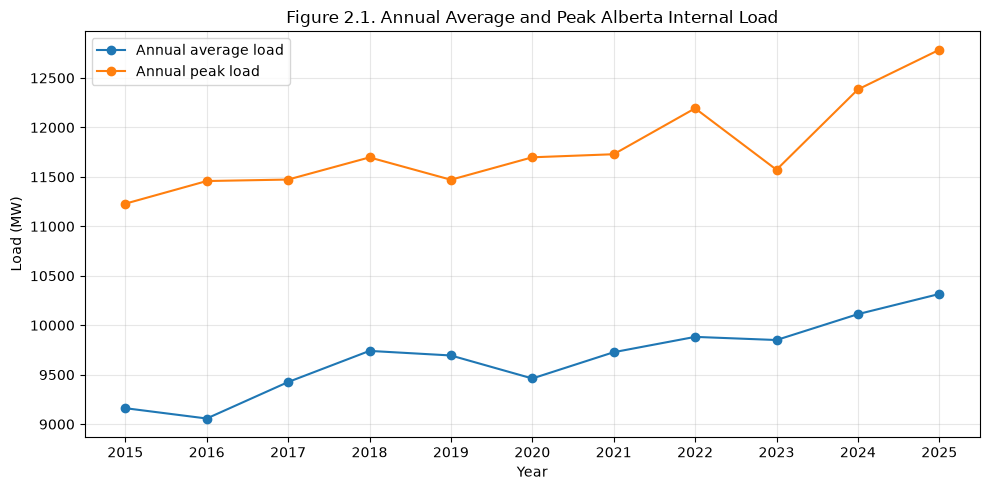

In [9]:
# ---------------------------------------------------------------------
# Visualize Long-Term Demand Trends
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(annual_load.index, annual_load["average_load_mw"], marker="o", label="Annual average load")
ax.plot(annual_load.index, annual_load["peak_load_mw"], marker="o", label="Annual peak load")

ax.set(
    title="Figure 2.1. Annual Average and Peak Alberta Internal Load",
    xlabel="Year",
    ylabel="Load (MW)",
    xticks=annual_load.index,
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

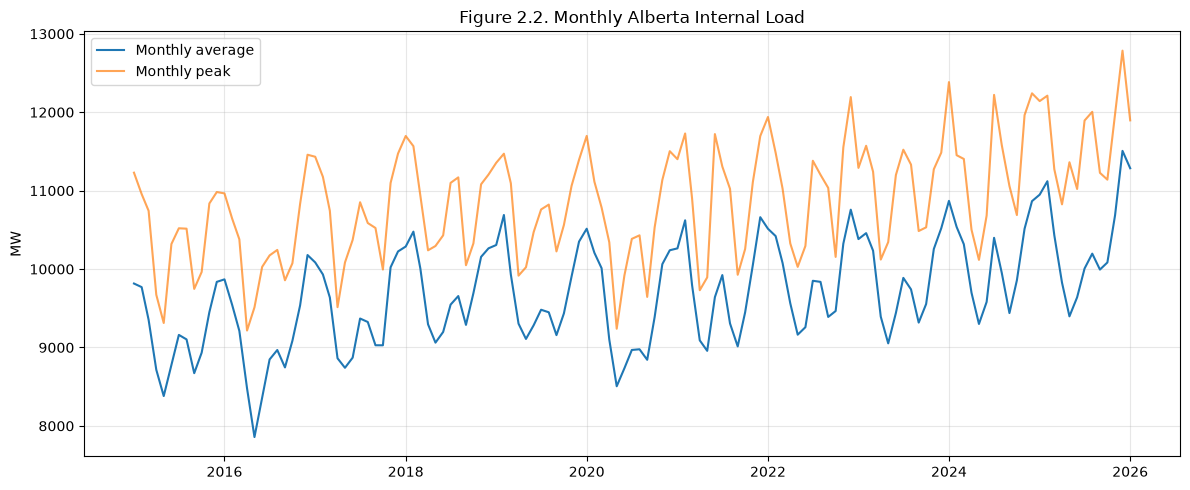

In [10]:
# ---------------------------------------------------------------------
# Visualize Monthly Demand Evolution
# ---------------------------------------------------------------------

monthly_load = (
    master.set_index("timestamp_utc")[load_col]
    .resample("MS")
    .agg(["mean", "max"])
    .rename(columns={"mean": "average_load_mw", "max": "peak_load_mw"})
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_load.index, monthly_load["average_load_mw"], label="Monthly average")
ax.plot(monthly_load.index, monthly_load["peak_load_mw"], alpha=0.7, label="Monthly peak")

ax.set(title="Figure 2.2. Monthly Alberta Internal Load", xlabel="", ylabel="MW")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### How Has Electricity Demand Changed?

Average Alberta internal load increased from 9,162 MW in 2015 to 10,316 MW in 2025, an increase of approximately 12.6% over the study period. Annual energy consumption rose from 80.26 TWh to 90.29 TWh over the same period.

Load growth was not uniform. Average load declined in 2016, 2019, 2020, and 2023, with the largest annual decrease occurring in 2020 at 2.4%. Growth resumed thereafter, reaching 2.7% in 2024 and 2.0% in 2025. Average load exceeded 10,000 MW for the first time in 2024 and increased further in 2025.

Peak load also increased over the study period, from 11,229 MW in 2015 to a new study-period maximum of 12,785 MW in 2025. The minimum hourly load reached 8,295 MW in 2025, also the highest annual minimum in the series. Together, the rising average, peak, and minimum loads indicate broad growth across Alberta’s load profile rather than an increase confined only to periods of peak demand.

### 2.2 How Has the Generation Mix Changed?

Alberta’s generation mix changed substantially over the study period, most notably through the decline of coal, expansion of gas-fired generation, and growth of wind and solar. Annual generation and generation shares are used to show how the composition of supply evolved from 2015 to 2025.

In [11]:
# ---------------------------------------------------------------------
# Summarize Annual Generation by Technology
# ---------------------------------------------------------------------

GENERATION_COLUMNS = {
    "Coal": "coal_system_generation", "Cogeneration": "cogeneration_system_generation",
    "Combined Cycle": "combined_cycle_system_generation", "Dual Fuel": "dual_fuel_system_generation",
    "Gas-Fired Steam": "gas_fired_steam_system_generation", "Hydro": "hydro_system_generation",
    "Other": "other_system_generation", "Simple Cycle": "simple_cycle_system_generation",
    "Solar": "solar_system_generation", "Storage": "storage_system_generation",
    "Wind": "wind_system_generation",
}

annual_generation_gwh = (
    master.groupby("year_alberta")[list(GENERATION_COLUMNS.values())]
    .sum(min_count=1)
    .div(1_000)
    .rename(columns={column: fuel for fuel, column in GENERATION_COLUMNS.items()})
)

display(annual_generation_gwh.round(1))

,Coal,Cogeneration,Combined Cycle,Dual Fuel,Gas-Fired Steam,Hydro,Other,Simple Cycle,Solar,Storage,Wind
year_alberta,,,,,,,,,,,
2015,39392.8,10357.8,5033.8,NaN,NaN,1708.2,570.3,703.8,NaN,NaN,4089.2
2016,38424.0,10427.4,5943.7,NaN,NaN,1733.0,609.1,741.0,NaN,NaN,4405.1
2017,37138.6,10933.4,7246.4,NaN,NaN,1887.2,515.8,888.1,0.1,NaN,4486.3
2018,28523.0,14066.5,9187.4,473.9,NaN,1861.2,651.6,2486.5,22.4,NaN,4104.1
2019,27199.9,14227.0,9652.2,708.6,NaN,1995.6,623.2,2815.2,20.3,NaN,4115.8
2020,20164.0,13795.4,10085.5,2243.3,NaN,2035.3,569.7,2453.8,86.3,0.1,6079.4
2021,15404.8,14321.1,9776.1,2606.6,3616.1,1818.2,697.5,3562.1,477.0,0.6,6132.9
2022,9711.9,13907.8,10703.7,597.9,10509.6,1922.6,651.1,3542.2,1163.9,0.7,7315.3
2023,6519.6,13515.3,10884.4,4038.7,10602.5,1688.8,698.0,2436.1,2311.2,1.8,10283.9


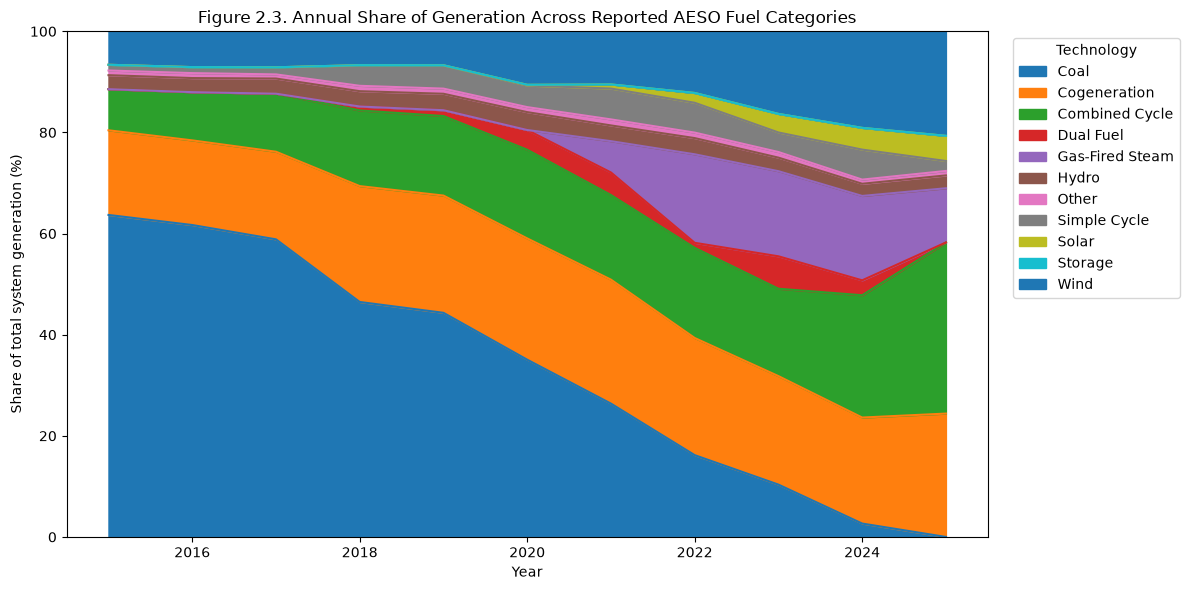

In [12]:
# ---------------------------------------------------------------------
# Visualize Annual Generation Shares
# ---------------------------------------------------------------------

annual_total_generation_gwh = (
    master.groupby("year_alberta")["total_system_generation"]
    .sum(min_count=1)
    .div(1_000)
)

annual_generation_share = annual_generation_gwh.div(annual_total_generation_gwh, axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
annual_generation_share.fillna(0).plot(kind="area", stacked=True, ax=ax)

ax.set(
    title="Figure 2.3. Annual Share of Generation Across Reported AESO Fuel Categories",
    xlabel="Year",
    ylabel="Share of total system generation (%)",
    ylim=(0, 100),
)
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### How Has the Generation Mix Changed?

Coal fell from roughly two-thirds of recorded generation in 2015 to less than 3% in 2024 and was no longer reported as a separate generation category in 2025. Alberta replaced coal generation primarily with dispatchable natural gas generation, particularly combined-cycle and cogeneration facilities, while wind and solar output also expanded substantially. In 2025, combined-cycle generation reached 23.6 TWh, cogeneration reached 17.0 TWh, wind reached 14.4 TWh, and solar reached 3.5 TWh.

Annual energy shares describe how technologies operated over the year, not their availability or performance during high-price or scarcity hours. Consequently, the changing generation mix alone does not indicate whether system reliability improved or deteriorated; Notebook 2 examines thermal availability, outages, and system margin directly.

> AESO fuel classifications changed during the transition. Dual Fuel appears in 2018, Gas-Fired Steam becomes a separate category in 2021, and Coal and Dual Fuel are later removed or reclassified. An unavailable plotted category indicates that no separate AESO category was reported, not necessarily that technically similar generation was absent.

### 2.3 How Has Reported Generation Capacity Changed?

Generation describes operation; reported maximum capacity describes fleet change. Comparing them separates actual output from nameplate capability.

> AESO Maximum Capacity is not firm capacity. Reported capacity can be unavailable because of planned maintenance, forced outages, wind and solar resource conditions, derates, or transmission constraints. A reported 23 GW supply stack does not imply that 23 GW is dispatchable or deliverable in a stressed hour.


In [13]:
# ---------------------------------------------------------------------
# Summarize Year-End Maximum Capacity by Technology
# ---------------------------------------------------------------------

CAPACITY_COLUMNS = {
    "Coal": "coal_maximum_capacity", "Cogeneration": "cogeneration_maximum_capacity",
    "Combined Cycle": "combined_cycle_maximum_capacity", "Simple Cycle": "simple_cycle_maximum_capacity",
    "Gas-Fired Steam": "gas_fired_steam_maximum_capacity", "Hydro": "hydro_maximum_capacity",
    "Other": "other_maximum_capacity", "Solar": "solar_maximum_capacity",
    "Storage": "storage_maximum_capacity", "Wind": "wind_maximum_capacity",
}
TOTAL_MAXIMUM_CAPACITY_COLUMN = "total_maximum_capacity"

capacity_columns = [*CAPACITY_COLUMNS.values(), TOTAL_MAXIMUM_CAPACITY_COLUMN]

annual_capacity_mw = (
    master.sort_values("timestamp_utc")
    .groupby("year_alberta", group_keys=False)
    .tail(1)
    .set_index("year_alberta")[capacity_columns]
    .rename(columns={
        **{column: technology for technology, column in CAPACITY_COLUMNS.items()},
        TOTAL_MAXIMUM_CAPACITY_COLUMN: "Reported Total",
    })
)

display(annual_capacity_mw.round(1))

,Coal,Cogeneration,Combined Cycle,Simple Cycle,Gas-Fired Steam,Hydro,Other,Solar,Storage,Wind,Reported Total
year_alberta,,,,,,,,,,,
2015,6289.0,4552.0,1758.0,946.0,NaN,894.0,386.0,NaN,NaN,1463.0,16288.0
2016,6299.0,4779.0,1745.0,866.0,NaN,894.0,395.0,NaN,NaN,1445.0,16423.0
2017,6003.0,4986.0,1745.0,866.0,NaN,894.0,392.0,15.0,NaN,1445.0,16346.0
2018,5568.0,4987.0,1790.0,871.0,NaN,894.0,381.0,15.0,NaN,1445.0,16106.0
2019,5183.0,5093.0,1790.0,855.0,NaN,894.0,381.0,15.0,NaN,1781.0,16532.0
2020,4132.0,5131.0,1798.0,1076.0,NaN,894.0,381.0,107.0,30.0,1781.0,16270.0
2021,2530.0,5247.0,1798.0,1182.0,1981.0,894.0,382.0,736.0,50.0,2269.0,17224.0
2022,820.0,5285.0,1852.0,1190.0,2609.0,894.0,402.0,1138.0,70.0,3618.0,18344.0
2023,820.0,5304.0,3052.0,909.0,2609.0,894.0,402.0,1650.0,190.0,4481.0,20777.0


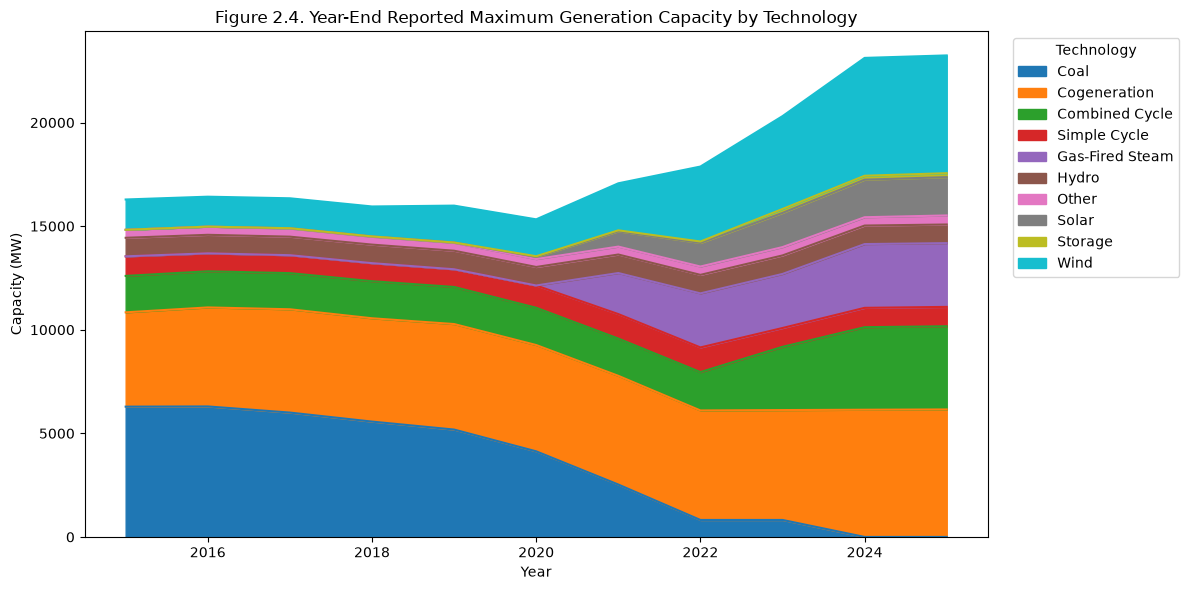

In [14]:
# ---------------------------------------------------------------------
# Visualize Maximum Generation Capacity
# ---------------------------------------------------------------------

technology_columns = list(CAPACITY_COLUMNS)

fig, ax = plt.subplots(figsize=(12, 6))
annual_capacity_mw[technology_columns].plot(kind="area", stacked=True, ax=ax)

ax.set(
    title="Figure 2.4. Year-End Reported Maximum Generation Capacity by Technology",
    xlabel="Year",
    ylabel="Capacity (MW)",
)
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

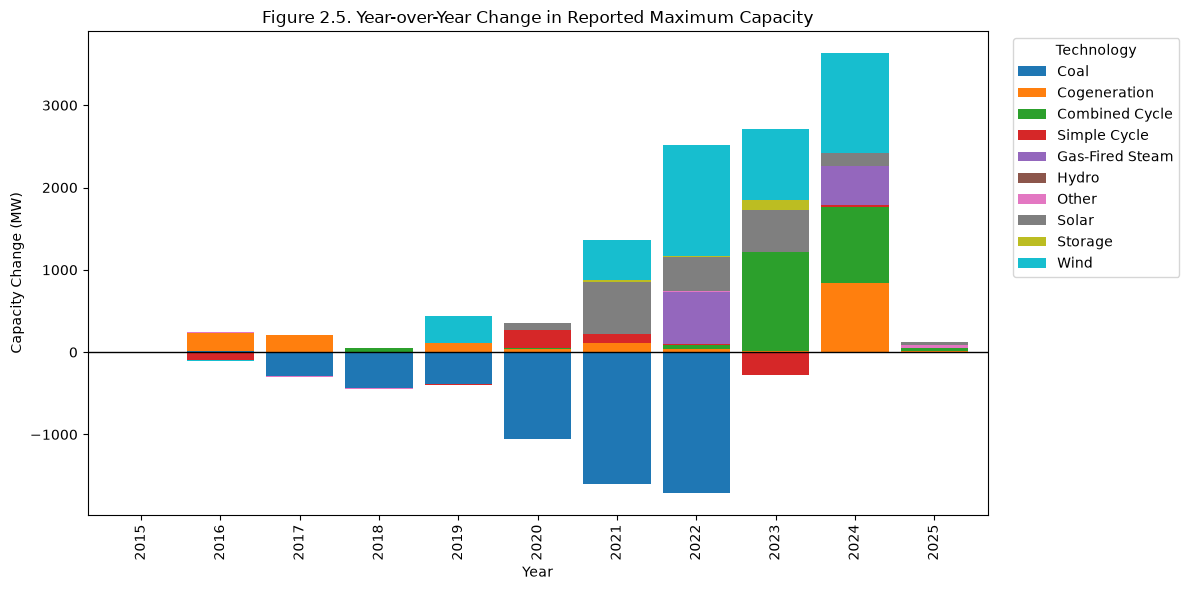

In [15]:
# ---------------------------------------------------------------------
# Visualize Year-over-Year Capacity Changes
# ---------------------------------------------------------------------

capacity_change_mw = annual_capacity_mw[technology_columns].diff()

fig, ax = plt.subplots(figsize=(12, 6))
capacity_change_mw.plot(kind="bar", stacked=True, width=0.85, ax=ax)

ax.axhline(0, color="black", linewidth=1)
ax.set(
    title="Figure 2.5. Year-over-Year Change in Reported Maximum Capacity",
    xlabel="Year",
    ylabel="Capacity Change (MW)",
)
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### How Has Reported Generation Capacity Changed?

Reported maximum generation capacity increased from approximately 16.3 GW in 2015 to 23.2 GW in 2025, an increase of about 43%. This growth accompanied Alberta’s transition away from coal toward a larger and more diversified generation fleet. Much of the retired or reclassified coal capacity was replaced by natural gas, while wind capacity increased from 1.5 GW to 5.7 GW and solar capacity grew from no separately reported capacity in 2015 to 1.9 GW in 2025. Storage capacity also emerged during the study period, reaching 190 MW by 2023. Some apparent technology-level changes reflect evolving AESO fuel classifications rather than purely physical additions or retirements.

Reported maximum capacity should not be interpreted as the amount of supply available during a high-price or scarcity hour. Thermal units may be offline or derated, renewable output depends on weather and time of day, hydro and storage operate under resource constraints, and intertie transfers are limited by available transmission capability. Consequently, Notebook 2 evaluates available supply relative to net load as a more meaningful representation of system tightness than reported maximum capacity alone.

### 2.4 How Has Intertie Usage Changed?

Interties connect Alberta with neighbouring electricity systems and can either supplement domestic supply or absorb excess generation. Annual import, export, and net-flow measures are compared to show how Alberta’s reliance on external power changed over the study period.

In [16]:
# ---------------------------------------------------------------------
# Summarize Annual Intertie Usage
# ---------------------------------------------------------------------

imports_col, exports_col, net_imports_col = "total_imports_mw", "total_exports_mw", "net_imports_mw"
INTERTIE_FULL_YEAR_END = 2024

annual_interties = (
    master.loc[master["year_alberta"].between(STUDY_START_YEAR, INTERTIE_FULL_YEAR_END)]
    .groupby("year_alberta")
    .agg(
        average_total_imports_mw=(imports_col, "mean"),
        peak_total_import_mw=(imports_col, "max"),
        total_import_energy_gwh=(imports_col, lambda s: s.sum(min_count=1) / 1_000),
        average_total_exports_mw=(exports_col, "mean"),
        total_export_energy_gwh=(exports_col, lambda s: s.sum(min_count=1) / 1_000),
        average_net_imports_mw=(net_imports_col, "mean"),
        peak_net_imports_mw=(net_imports_col, "max"),
        minimum_net_imports_mw=(net_imports_col, "min"),
        net_importing_hours=("is_net_importing", "sum"),
        net_exporting_hours=("is_net_exporting", "sum"),
    )
)

annual_interties["net_import_energy_gwh"] = (
    annual_interties["total_import_energy_gwh"] - annual_interties["total_export_energy_gwh"]
)

display(annual_interties.round(2))

,average_total_imports_mw,peak_total_import_mw,total_import_energy_gwh,average_total_exports_mw,total_export_energy_gwh,average_net_imports_mw,peak_net_imports_mw,minimum_net_imports_mw,net_importing_hours,net_exporting_hours,net_import_energy_gwh
year_alberta,,,,,,,,,,,
2015,124.57,1002.0,1091.22,74.26,650.55,50.30,1002.0,-877.0,4151,2982,440.67
2016,49.52,769.0,435.02,98.67,866.74,-49.15,729.0,-935.0,2408,3749,-431.72
2017,147.79,998.0,1294.66,116.62,1021.61,31.17,998.0,-935.0,3104,4363,273.05
2018,387.42,1092.0,3393.79,83.40,730.60,304.02,1092.0,-1010.0,6390,1890,2663.19
2019,243.43,1154.0,2132.42,69.65,610.13,173.78,1154.0,-939.0,6368,1765,1522.29
2020,451.45,1118.0,3965.51,11.13,97.80,440.31,1118.0,-332.0,8387,75,3867.71
2021,473.81,1059.0,4150.55,15.01,131.46,458.80,1022.0,-532.0,8550,150,4019.09
2022,484.41,983.0,4243.42,71.95,630.31,412.46,983.0,-939.0,7810,942,3613.11
2023,248.57,888.0,2177.47,247.62,2169.12,0.95,888.0,-1026.0,5243,3466,8.35


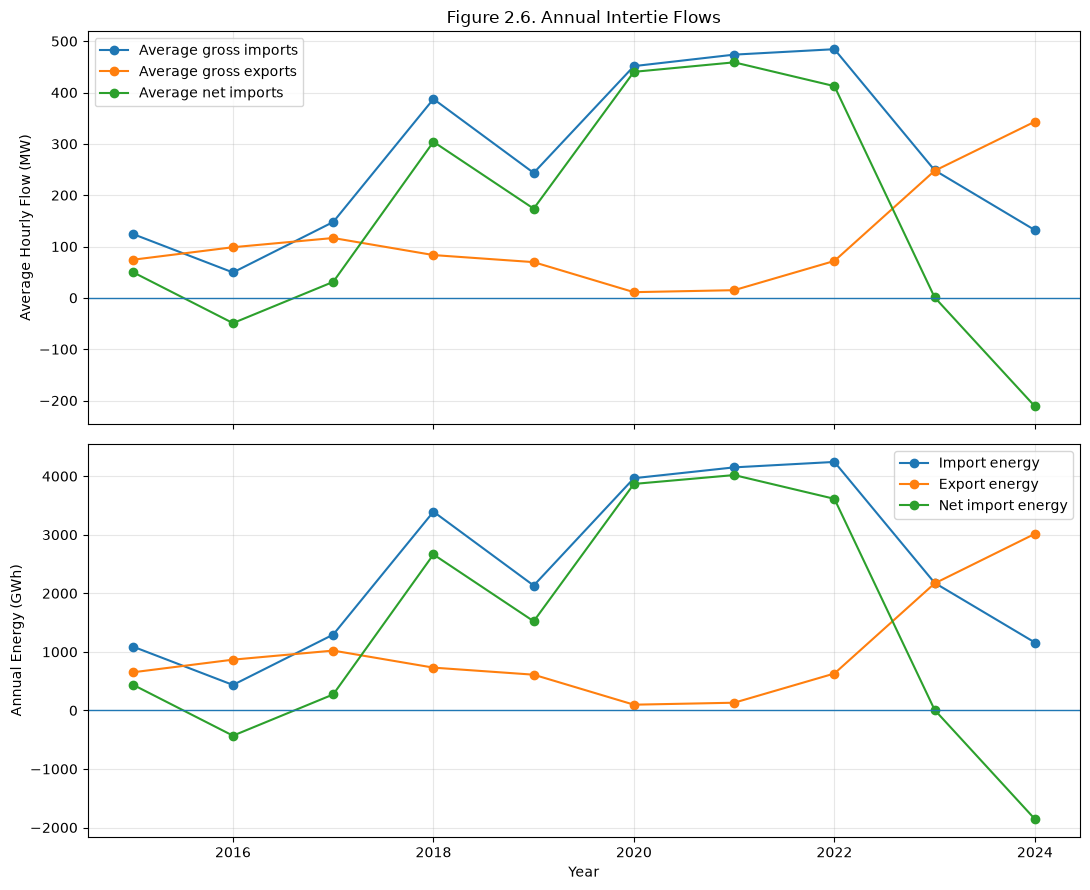

In [17]:
# ---------------------------------------------------------------------
# Visualize Annual Intertie Flows and Energy Balances
# ---------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

for column, label in {
    "average_total_imports_mw": "Average gross imports",
    "average_total_exports_mw": "Average gross exports",
    "average_net_imports_mw": "Average net imports",
}.items():
    axes[0].plot(annual_interties.index, annual_interties[column], marker="o", label=label)

axes[0].axhline(0, linewidth=1)
axes[0].set(title="Figure 2.6. Annual Intertie Flows", ylabel="Average Hourly Flow (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for column, label in {
    "total_import_energy_gwh": "Import energy",
    "total_export_energy_gwh": "Export energy",
    "net_import_energy_gwh": "Net import energy",
}.items():
    axes[1].plot(annual_interties.index, annual_interties[column], marker="o", label=label)

axes[1].axhline(0, linewidth=1)
axes[1].set(xlabel="Year", ylabel="Annual Energy (GWh)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# ---------------------------------------------------------------------
# Summarize Imports Relative to Alberta Internal Load
# ---------------------------------------------------------------------

annual_import_share = (
    (master[imports_col] / master[load_col] * 100)
    .groupby(master["year_alberta"])
    .agg(
        average_import_share_pct="mean",
        median_import_share_pct="median",
        p95_import_share_pct=lambda s: s.quantile(0.95),
    )
)

display(annual_import_share.round(2))

,average_import_share_pct,median_import_share_pct,p95_import_share_pct
year_alberta,,,
2015,1.30,0.47,6.27
2016,0.55,0.00,3.13
2017,1.66,0.00,9.18
2018,4.03,3.16,10.24
2019,2.53,1.66,8.86
2020,4.82,4.17,10.72
2021,4.82,4.70,8.53
2022,4.90,5.06,8.73
2023,2.54,2.16,5.81


#### How Has Intertie Usage Changed?

Alberta transitioned from broadly balanced electricity trade during 2015–2017 to sustained net imports through 2022, with net-import energy peaking at approximately 4.0 TWh in 2021. Trade was nearly balanced in 2023, and by 2024 Alberta had become a net exporter, recording approximately 1.9 TWh of net-export energy.

Despite this shift in annual net trade, large imports and exports continued throughout the study period. Annual net imports therefore represent the balance of two-way electricity trade rather than one-way dependence on neighbouring jurisdictions. Intertie data coverage extends into 2025, but the available record does not represent a complete calendar year; therefore, 2025 values are retained for operational analysis but excluded from annual trade comparisons. Notebook 2 examines when Alberta relies on imports and whether available transfer capability becomes constrained during tight system conditions.

### 2.5 Section Summary

Section 2 establishes the main structural changes in Alberta’s electricity market over the study period. Demand increased, the generation fleet expanded and changed composition, coal generation disappeared, wind became a larger source of supply, and intertie usage evolved alongside these changes. The summary below compares several of these shifts directly before moving to the market’s hourly operating patterns.

In [21]:
# ---------------------------------------------------------------------
# Summarize Key Structural Changes
# ---------------------------------------------------------------------

first_year, final_year = STUDY_START_YEAR, STUDY_END_YEAR
coal_final_year, trade_final_year = 2024, INTERTIE_FULL_YEAR_END

section_2_summary = pd.DataFrame({
    "metric": [
        "Average load", "Peak load", "Annual electricity consumption",
        "Coal share of total system generation", "Wind share of total system generation",
        "Reported maximum generation capacity", "Average net imports", "Net import energy",
    ],
    "start_year": first_year,
    "end_year": [
        final_year, final_year, final_year, coal_final_year,
        final_year, final_year, trade_final_year, trade_final_year,
    ],
    "start_value": [
        annual_load.loc[first_year, "average_load_mw"],
        annual_load.loc[first_year, "peak_load_mw"],
        annual_load.loc[first_year, "annual_energy_twh"],
        annual_generation_share.loc[first_year, "Coal"],
        annual_generation_share.loc[first_year, "Wind"],
        annual_capacity_mw.loc[first_year, "Reported Total"],
        annual_interties.loc[first_year, "average_net_imports_mw"],
        annual_interties.loc[first_year, "net_import_energy_gwh"],
    ],
    "end_value": [
        annual_load.loc[final_year, "average_load_mw"],
        annual_load.loc[final_year, "peak_load_mw"],
        annual_load.loc[final_year, "annual_energy_twh"],
        annual_generation_share.loc[coal_final_year, "Coal"],
        annual_generation_share.loc[final_year, "Wind"],
        annual_capacity_mw.loc[final_year, "Reported Total"],
        annual_interties.loc[trade_final_year, "average_net_imports_mw"],
        annual_interties.loc[trade_final_year, "net_import_energy_gwh"],
    ],
    "unit": ["MW", "MW", "TWh", "%", "%", "MW", "MW", "GWh"],
})

section_2_summary["change"] = section_2_summary["end_value"] - section_2_summary["start_value"]

display(section_2_summary.style.format({
    "start_year": "{:.0f}", "end_year": "{:.0f}",
    "start_value": "{:,.2f}", "end_value": "{:,.2f}", "change": "{:+,.2f}",
}))

,metric,start_year,end_year,start_value,end_value,unit,change
0,Average load,2015,2025,"9,161.75","10,316.30",MW,"+1,154.55"
1,Peak load,2015,2025,"11,229.00","12,785.00",MW,"+1,556.00"
2,Annual electricity consumption,2015,2025,80.26,90.37,TWh,+10.11
3,Coal share of total system generation,2015,2024,63.68,2.65,%,-61.04
4,Wind share of total system generation,2015,2025,6.61,20.66,%,+14.05
5,Reported maximum generation capacity,2015,2025,"16,288.00","23,242.00",MW,"+6,954.00"
6,Average net imports,2015,2024,50.30,-211.26,MW,-261.57
7,Net import energy,2015,2024,440.67,"-1,855.75",GWh,"-2,296.41"


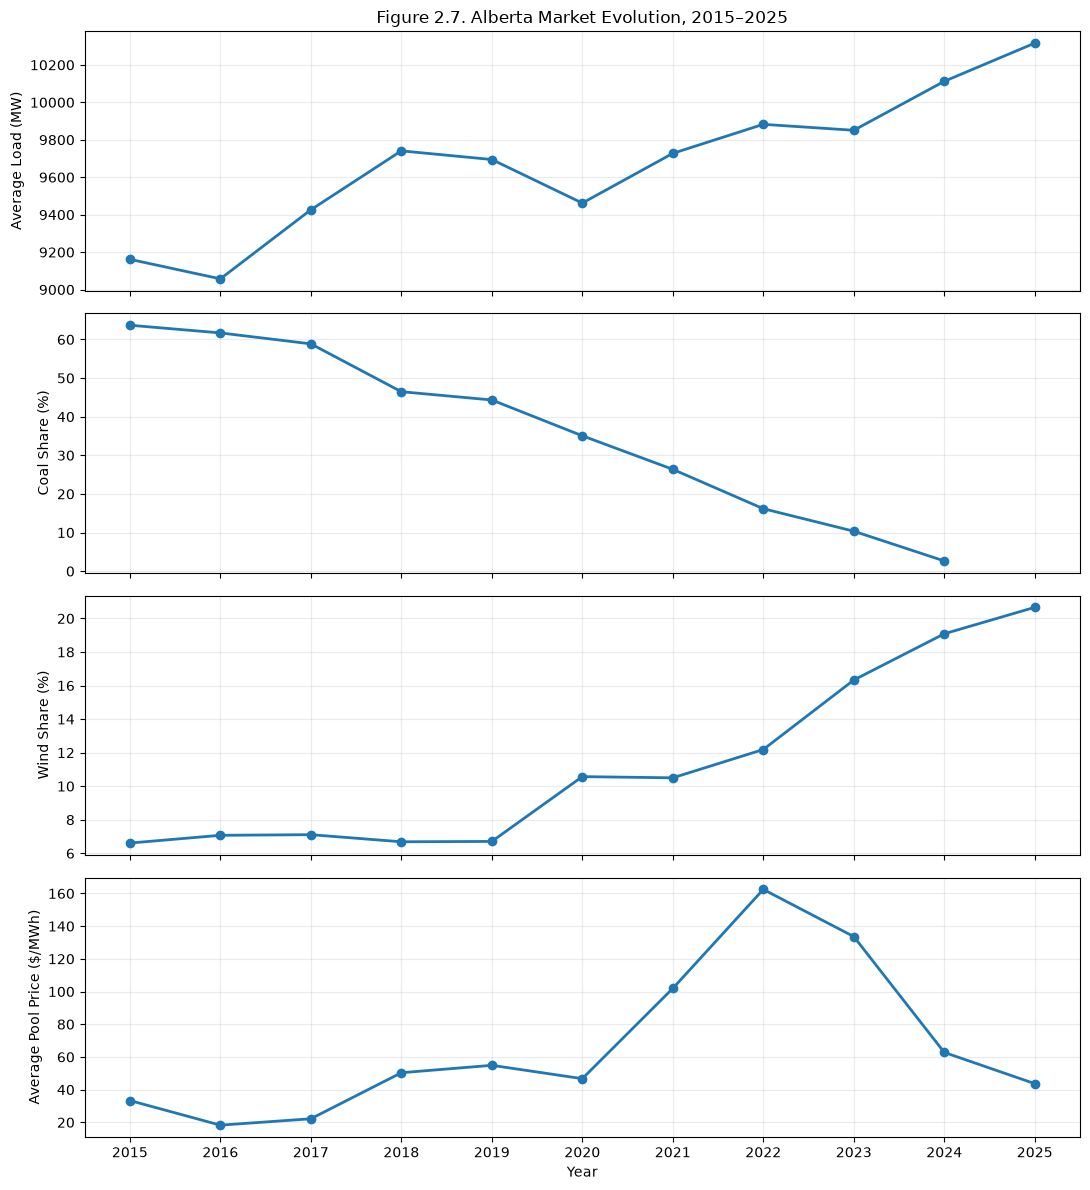

In [22]:
# ---------------------------------------------------------------------
# Visualize Alberta Market Evolution
# ---------------------------------------------------------------------

market_evolution = pd.DataFrame({
    "Average Load (MW)": annual_load["average_load_mw"],
    "Coal Share (%)": annual_generation_share["Coal"],
    "Wind Share (%)": annual_generation_share["Wind"],
    "Average Pool Price ($/MWh)": master.groupby("year_alberta")["pool_price"].mean(),
})

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

for ax, column in zip(axes, market_evolution):
    ax.plot(market_evolution.index, market_evolution[column], marker="o", linewidth=2)
    ax.set_ylabel(column)
    ax.grid(alpha=0.25)

axes[0].set_title("Figure 2.7. Alberta Market Evolution, 2015–2025")
axes[-1].set(xlabel="Year", xticks=market_evolution.index)

plt.tight_layout()
plt.show()

#### Section Summary

From 2015 to 2025, Alberta’s electricity market underwent substantial structural change. Average load increased by 1,154 MW, from 9,162 MW to 10,316 MW, while peak load rose by 1,556 MW to 12,785 MW. Annual electricity consumption increased by 10.03 TWh, reaching 90.29 TWh in 2025.

The supply mix changed even more dramatically. Coal accounted for 63.7% of recorded generation in 2015 but was no longer reported as a separate generation category in 2025, following the conversion of Alberta’s remaining coal-fired units to natural gas. Wind’s share of total system generation increased from 6.6% to 20.7%. Natural-gas technologies became central to dispatchable supply, solar generation expanded, and reported maximum generation capacity increased by 6,954 MW to 23,242 MW.

Using complete calendar years, Alberta’s annual trade position also shifted substantially toward exports. Average net imports declined from 50 MW in 2015 to −211 MW in 2024, while net-import energy moved from positive 441 GWh to −1,856 GWh, indicating approximately 1.86 TWh of net exports in 2024. Intertie reporting ends in July 2025, so partial-year 2025 flows are excluded from the annual comparison.

Together, these developments altered both the composition of supply and the operating conditions under which the market clears. They also motivate one of the central concepts used throughout the remainder of the project: net load. Gross load measures electricity demand, whereas net load approximates the demand that must be met by dispatchable generation after variable renewable output is removed. Notebook 2 uses net load to evaluate scarcity and system tightness, while Notebook 4 examines how weather-driven wind, solar, and demand variability create those net-load conditions.

The next section shifts from long-term structural change to Alberta’s recurring hourly operating patterns.

## Section 3 — Normal Operating Patterns

Before focusing on the price tail, this section establishes the market’s normal operating rhythm. It summarizes how load, renewables, imports, and price vary across the day, between weekdays and weekends, and across seasons. These recurring patterns provide a baseline for distinguishing ordinary variation from genuinely unusual or stressed conditions later in the notebook.

### 3.1 System-Wide Operating Profile

The first step is to compare the typical daily shape of the main operating variables. Normalized system-wide profiles are followed by more detailed views of load, imports, price, wind, and solar to show how Alberta’s operating state changes over a typical day.

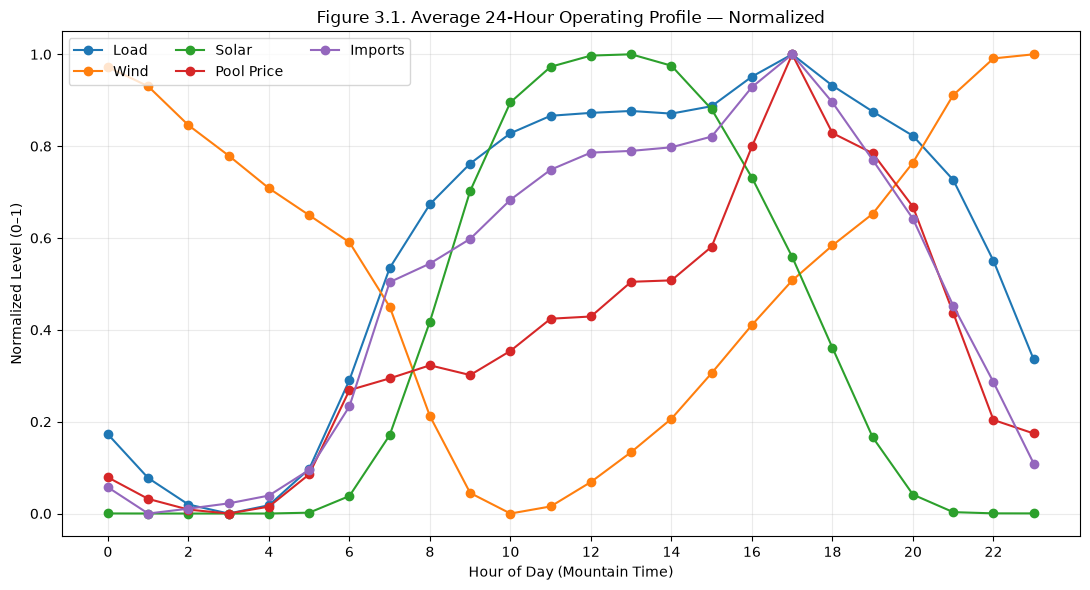

In [23]:
# ---------------------------------------------------------------------
# Compare Average Daily Operating Profiles
# ---------------------------------------------------------------------

operating_profile_columns = {
    "Load": "ail_mw", "Wind": "wind_system_generation",
    "Solar": "solar_system_generation", "Pool Price": "pool_price",
    "Imports": "total_imports_mw",
}

average_operating_profile = (
    master.groupby("hour_alberta")[list(operating_profile_columns.values())]
    .mean()
    .rename(columns={value: key for key, value in operating_profile_columns.items()})
)

normalized_operating_profile = (
    (average_operating_profile - average_operating_profile.min())
    / (average_operating_profile.max() - average_operating_profile.min())
)

fig, ax = plt.subplots(figsize=(11, 6))

for column in normalized_operating_profile:
    ax.plot(normalized_operating_profile.index, normalized_operating_profile[column], marker="o", label=column)

ax.set(
    title="Figure 3.1. Average 24-Hour Operating Profile — Normalized",
    xlabel="Hour of Day (Mountain Time)",
    ylabel="Normalized Level (0–1)",
    xticks=range(0, 24, 2),
)
ax.legend(ncol=3)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### System-Wide Operating Profile

The combined figure illustrates Alberta's daily supply-demand balance: load, imports, and prices rise toward the late-afternoon peak, wind is generally strongest overnight, and solar peaks around midday. Normalization emphasizes timing rather than magnitude, highlighting the mismatch between renewable production and demand. This temporal mismatch motivates net load as a more informative representation of system conditions than gross load alone when examining scarcity and price formation.

### 3.2 Typical Hourly Demand Profile

Alberta demand follows a clear intraday cycle, reflecting recurring changes in residential, commercial, and industrial activity. Mean and median hourly load are compared to show the typical shape of demand across the day and whether higher-demand periods materially influence the average profile.

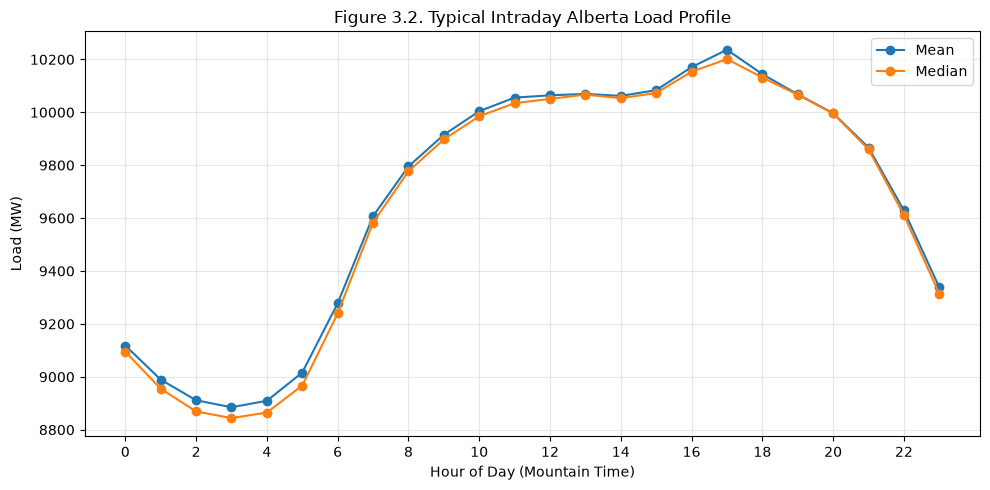

In [24]:
# ---------------------------------------------------------------------
# Summarize Typical Hourly Load Profile
# ---------------------------------------------------------------------

hourly_load_profile = master.groupby("hour_alberta")[load_col].agg(["mean", "median"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_load_profile.index, hourly_load_profile["mean"], marker="o", label="Mean")
ax.plot(hourly_load_profile.index, hourly_load_profile["median"], marker="o", label="Median")

ax.set(
    title="Figure 3.2. Typical Intraday Alberta Load Profile",
    xlabel="Hour of Day (Mountain Time)",
    ylabel="Load (MW)",
    xticks=range(0, 24, 2),
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Typical Hourly Demand Profile

Load is lowest around 03:00–04:00, rises through the morning, and peaks near 17:00 before declining through the evening. The close agreement between the mean and median profiles indicates that this intraday pattern is stable despite substantial day-to-day variability.

### 3.3 Weekday Versus Weekend Demand

Weekday and weekend demand differ in both level and intraday shape as patterns of commercial, industrial, and residential activity change. Comparing the two profiles shows how the normal daily demand cycle depends on the type of day.

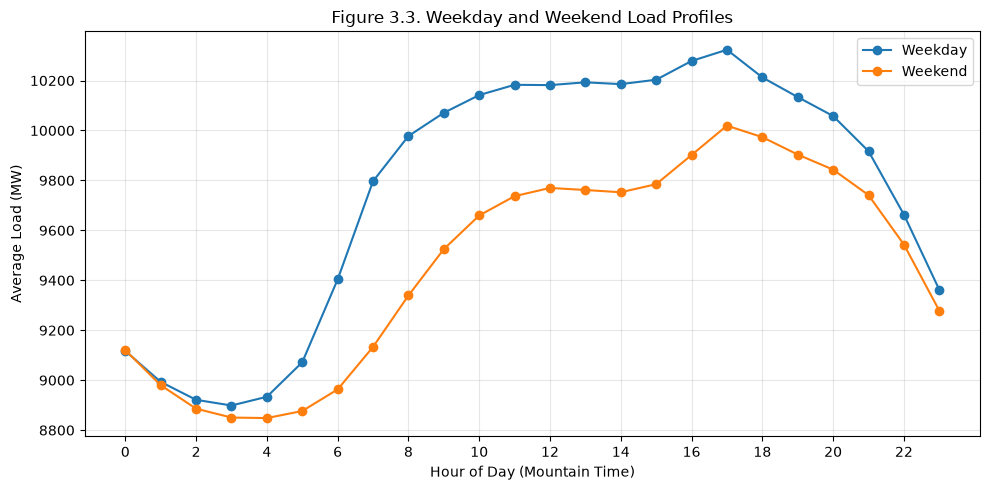

In [25]:
# ---------------------------------------------------------------------
# Compare Weekday and Weekend Load Profiles
# ---------------------------------------------------------------------

weekday_profile = (
    master.groupby(["hour_alberta", "is_weekend"])[load_col]
    .mean()
    .unstack()
    .rename(columns={False: "Weekday", True: "Weekend"})
)

fig, ax = plt.subplots(figsize=(10, 5))

for column in weekday_profile:
    ax.plot(weekday_profile.index, weekday_profile[column], marker="o", label=column)

ax.set(
    title="Figure 3.3. Weekday and Weekend Load Profiles",
    xlabel="Hour of Day (Mountain Time)",
    ylabel="Average Load (MW)",
    xticks=range(0, 24, 2),
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Weekday and Weekend Demand Profiles

Weekday and weekend demand follow similar daily profiles, but weekday demand is consistently higher between roughly 06:00 and 18:00. This pattern is consistent with greater daytime commercial and industrial activity, although aggregate load data do not directly identify the contributing sectors.

### 3.4 Seasonal Demand Profiles

Seasonal conditions change both the level and daily shape of electricity demand. Comparing hourly profiles across winter, spring, summer, and fall shows when seasonal demand is highest and how the timing of daily peaks changes throughout the year.

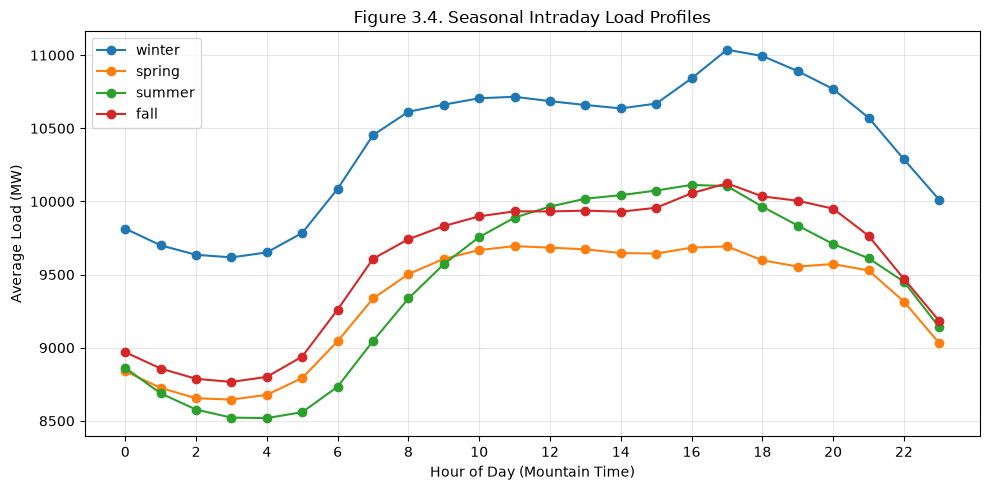

In [26]:
# ---------------------------------------------------------------------
# Compare Seasonal Intraday Load Profiles
# ---------------------------------------------------------------------

season_order = ["winter", "spring", "summer", "fall"]

seasonal_load_profile = (
    master.groupby(["hour_alberta", "season"])[load_col]
    .mean()
    .unstack()
    .reindex(columns=season_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

for season in seasonal_load_profile:
    ax.plot(seasonal_load_profile.index, seasonal_load_profile[season], marker="o", label=season)

ax.set(
    title="Figure 3.4. Seasonal Intraday Load Profiles",
    xlabel="Hour of Day (Mountain Time)",
    ylabel="Average Load (MW)",
    xticks=range(0, 24, 2),
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Seasonal Demand Profiles

Winter records the highest typical loads and spring the lowest. Every season retains the same broad daily structure, with an overnight minimum, morning ramp, and late-afternoon peak. The higher winter demand is consistent with heating requirements and other seasonal patterns of electricity use.

### 3.5 Typical Price and Import Profiles

Price and imports also follow recurring intraday patterns. Median hourly profiles are used to reduce the influence of extreme price events and show how typical market prices and reliance on imported power vary across the day.

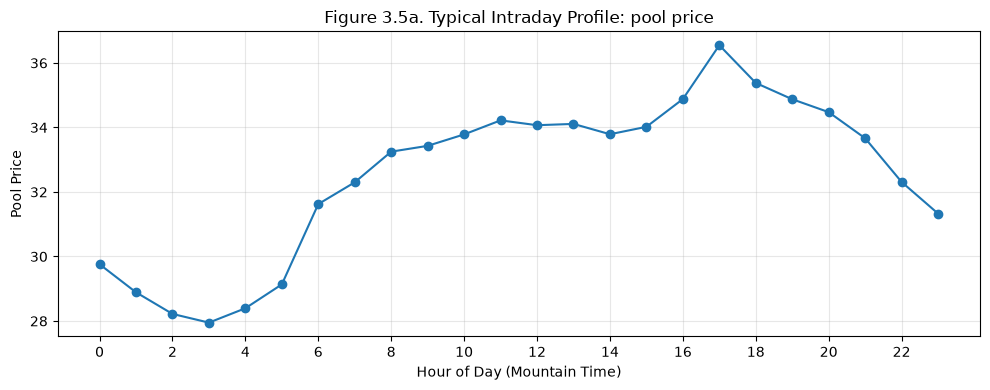

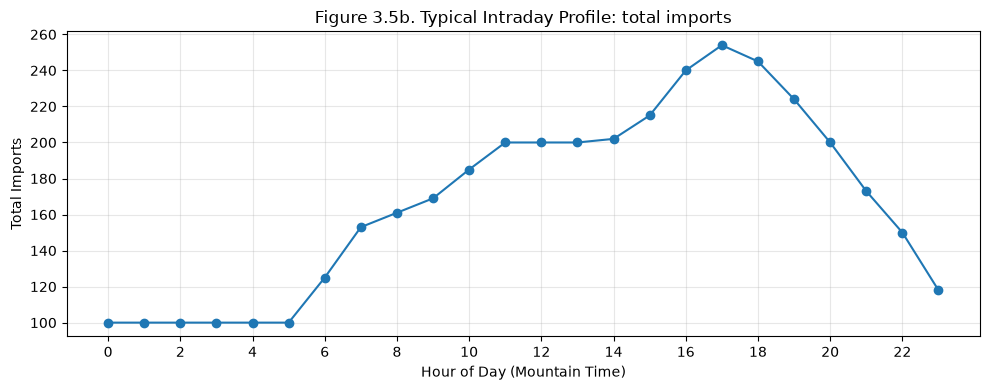

In [27]:
# ---------------------------------------------------------------------
# Compare Typical Intraday Price and Import Profiles
# ---------------------------------------------------------------------

profile_variables = {"Pool Price": "pool_price", "Total Imports": "total_imports_mw"}
profile_figure_numbers = {"Pool Price": "3.5a", "Total Imports": "3.5b"}

for label, column in profile_variables.items():
    profile = master.groupby("hour_alberta")[column].median()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(profile.index, profile.values, marker="o")

    ax.set(
        title=f"Figure {profile_figure_numbers[label]}. Typical Intraday Profile: {label.lower()}",
        xlabel="Hour of Day (Mountain Time)",
        ylabel=label,
        xticks=range(0, 24, 2),
    )
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Typical Price and Import Profiles

Imports and pool prices rise toward the late-afternoon demand peak. Their similar timing does not establish direction: imports may respond to Alberta high-price conditions rather than cause higher prices. Notebook 2 evaluates import reliance and transfer-capability utilization during tight conditions; Notebook 5 later examines whether intertie behaviour leads or follows price movements.

### 3.6 Seasonal Solar and Wind Profiles

Wind and solar generation vary differently across both the day and the year. Seasonal hourly profiles show the predictable daylight-driven pattern of solar generation alongside the less regular intraday structure of wind output.

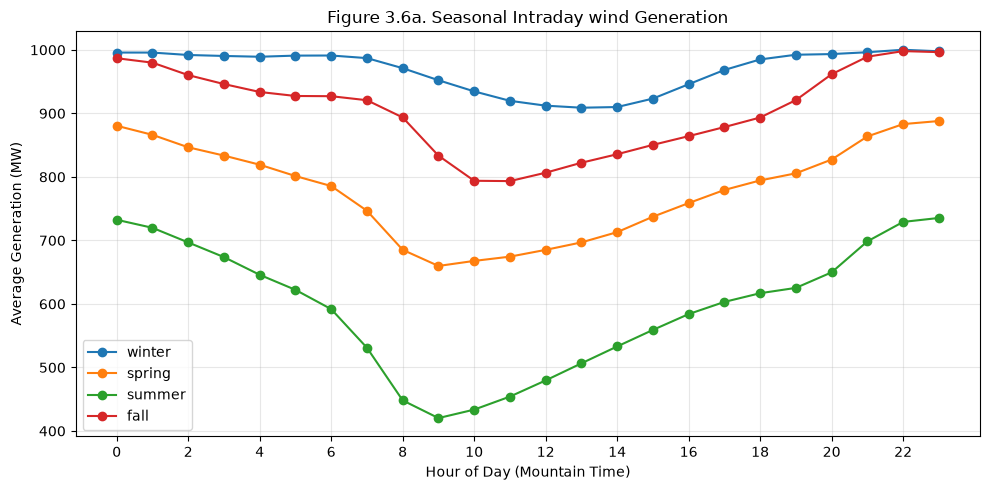

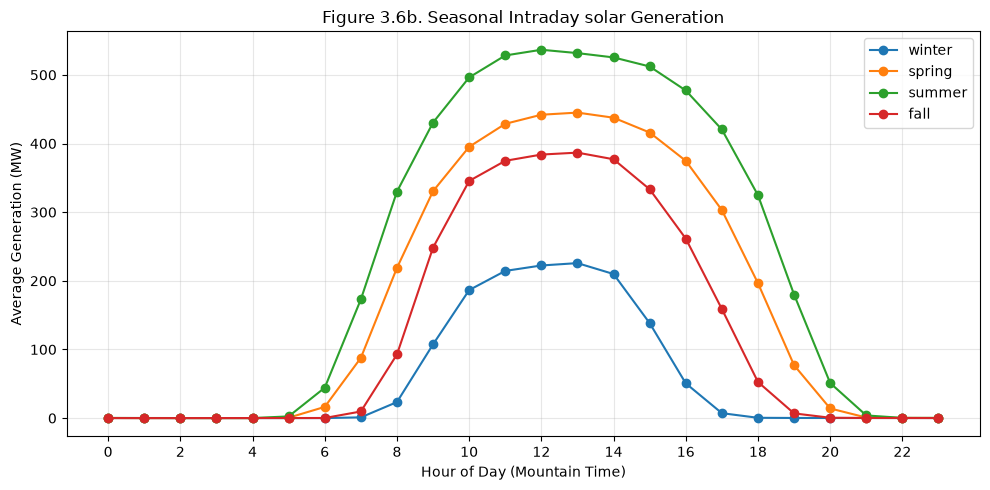

In [28]:
# ---------------------------------------------------------------------
# Compare Seasonal Wind and Solar Profiles
# ---------------------------------------------------------------------

renewable_profile_variables = {"Wind": "wind_system_generation", "Solar": "solar_system_generation"}
renewable_figure_numbers = {"Wind": "3.6a", "Solar": "3.6b"}

for label, column in renewable_profile_variables.items():
    seasonal_profile = (
        master.groupby(["hour_alberta", "season"])[column]
        .mean()
        .unstack()
        .reindex(columns=season_order)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for season in seasonal_profile:
        ax.plot(seasonal_profile.index, seasonal_profile[season], marker="o", label=season)

    ax.set(
        title=f"Figure {renewable_figure_numbers[label]}. Seasonal Intraday {label.lower()} Generation",
        xlabel="Hour of Day (Mountain Time)",
        ylabel="Average Generation (MW)",
        xticks=range(0, 24, 2),
    )
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Seasonal Wind and Solar Generation Profiles

Wind is generally strongest in winter and weakest in summer. Solar peaks around midday and during summer, while Alberta's highest demand typically occurs during winter and the late afternoon. This timing mismatch reinforces the use of net load rather than gross load, while capacity-adjusted output provides a more meaningful comparison as the renewable fleet expands.

## Section 4 — How Variable Is the Market?

The operating profiles define normal conditions, but averages conceal the price tails that matter most for forecasting. This section moves from typical operation to distributions, exceedances, and market regimes.

### 4.1 Distribution Summary

In [24]:
# ---------------------------------------------------------------------
# Summarize the distributions of major market variables
# ---------------------------------------------------------------------

distribution_columns = {
    "Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

distribution_summary = pd.DataFrame({
    label: master[column].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    for label, column in distribution_columns.items()
}).T

distribution_summary.columns = [
    "p01",
    "p05",
    "p25",
    "median",
    "p75",
    "p95",
    "p99",
]

display(distribution_summary.round(3))

,p01,p05,p25,median,p75,p95,p99
Load,7768.000,8230.000,9077.000,9672.00,10300.000,11081.000,11646.000
Pool Price,0.000,12.370,20.440,32.85,53.280,244.440,777.250
AECO Gas,-0.025,0.450,1.630,2.29,2.745,5.200,7.000
Spark Spread,-11.352,-3.852,5.915,18.05,33.088,220.889,755.480
Net Imports,-935.000,-675.000,-79.000,100.00,429.000,825.000,949.000
Total Imports,0.000,0.000,25.000,161.00,444.000,837.000,950.000
Total Exports,0.000,0.000,0.000,0.00,147.000,746.000,974.000
Total Outages,2161.886,2413.565,3011.400,3481.40,3999.700,4941.400,5655.322


#### Distribution Summary

Load and total outages vary within bounded physical ranges, although outages exhibit substantial variation across operating conditions. Pool price and spark spread are strongly right-skewed: median values are \$32.85/MWh and \$18.05/MWh, respectively, while their 99th percentiles reach \$777.27/MWh and \$755.48/MWh. AECO gas prices also vary considerably and are occasionally negative.

Intertie flows span both importing and exporting conditions. Net imports range from −935 MW at the 1st percentile to 949 MW at the 99th percentile, while the separate import and export distributions contain many zero-flow hours and are therefore asymmetric.

These distributions motivate quantile-, regime-, and event-based analyses rather than reliance on averages alone. Many of Alberta’s most operationally and economically significant market conditions occur in the tails of these distributions.

### 4.2 Histograms

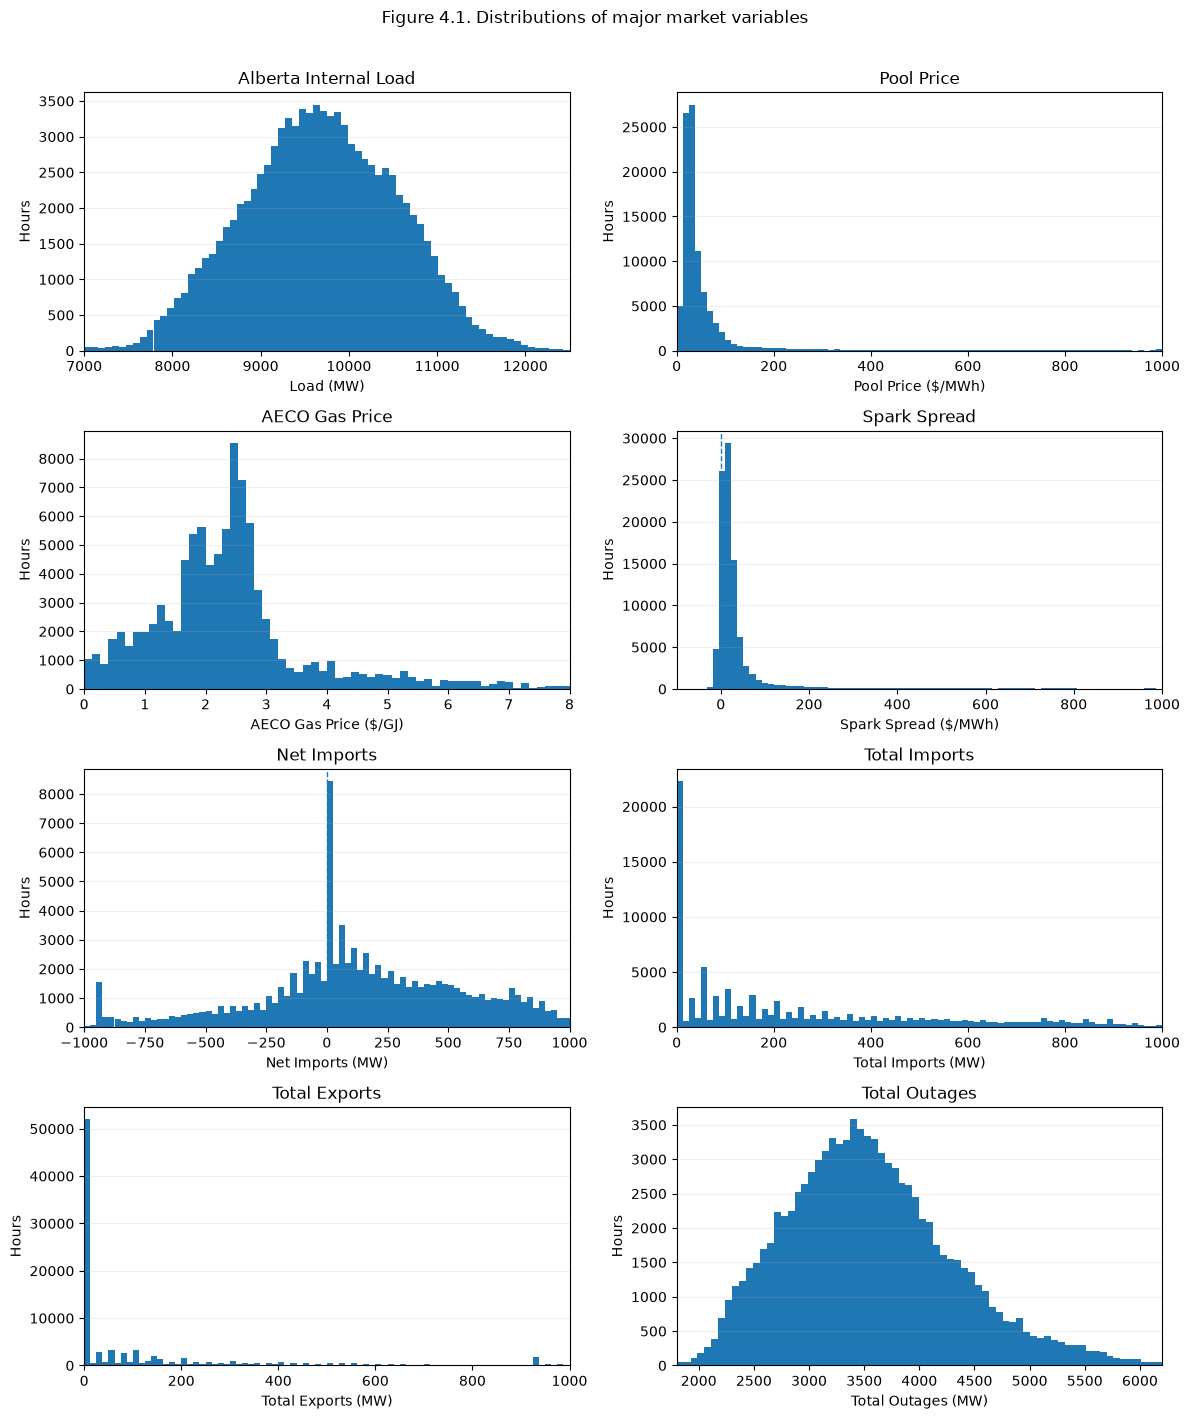

In [25]:
# ---------------------------------------------------------------------
# Visualize major market-variable distributions in a compact panel
# ---------------------------------------------------------------------

histogram_variables = {
    "Alberta Internal Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas Price": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

# Display ranges emphasize the main body of each distribution.
# Observations outside these ranges remain represented in the
# quantile, exceedance, and price-duration summaries.
display_limits = {
    "Alberta Internal Load": (7000, 12500),
    "Pool Price": (0, 1000),
    "AECO Gas Price": (0, 8),
    "Spark Spread": (-100, 1000),
    "Net Imports": (-1000, 1000),
    "Total Imports": (0, 1000),
    "Total Exports": (0, 1000),
    "Total Outages": (1800, 6200),
}

# Domain-specific bin counts chosen to balance detail and readability.
histogram_bins = {
    "Alberta Internal Load": 70,
    "Pool Price": 80,
    "AECO Gas Price": 60,
    "Spark Spread": 80,
    "Net Imports": 80,
    "Total Imports": 80,
    "Total Exports": 80,
    "Total Outages": 70,
}

axis_labels = {
    "Alberta Internal Load": "Load (MW)",
    "Pool Price": "Pool Price ($/MWh)",
    "AECO Gas Price": "AECO Gas Price ($/GJ)",
    "Spark Spread": "Spark Spread ($/MWh)",
    "Net Imports": "Net Imports (MW)",
    "Total Imports": "Total Imports (MW)",
    "Total Exports": "Total Exports (MW)",
    "Total Outages": "Total Outages (MW)",
}

signed_variables = {
    "Spark Spread",
    "Net Imports",
}

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 14),
)

fig.suptitle(
    "Figure 4.1. Distributions of major market variables",
    y=1.01,
)

for ax, (title, column) in zip(
    axes.flat,
    histogram_variables.items(),
):
    lower_limit, upper_limit = display_limits[title]

    # Restrict the displayed sample before calculating bin edges.
    # This prevents extreme observations outside the plotted domain
    # from compressing the visible distribution into a few bins.
    displayed_values = (
        master.loc[
            master[column].between(
                lower_limit,
                upper_limit,
                inclusive="both",
            ),
            column,
        ]
        .dropna()
    )

    bin_edges = np.linspace(
        lower_limit,
        upper_limit,
        histogram_bins[title] + 1,
    )

    ax.hist(
        displayed_values,
        bins=bin_edges,
    )

    if title in signed_variables:
        ax.axvline(
            0,
            linewidth=1,
            linestyle="--",
        )

    ax.set_xlim(lower_limit, upper_limit)
    ax.set_title(title)
    ax.set_xlabel(axis_labels[title])
    ax.set_ylabel("Hours")
    ax.grid(
        axis="y",
        alpha=0.2,
    )

plt.tight_layout()
plt.show()

#### Distribution Characteristics

Load and outages are comparatively concentrated, while pool price and spark spread exhibit long right tails. Gas prices are moderately skewed, and intertie flows are asymmetric: imports and especially exports are concentrated at lower values with occasional large flows.

The contrast between relatively stable physical quantities and highly volatile economic outcomes motivates threshold, quantile, and regime-based analysis. Notebook 3 evaluates whether gas prices and thermal economics explain ordinary price variation differently across fuel-price and system-tightness conditions.

> Display ranges emphasize the main body of each distribution; extreme values remain represented in the quantile, exceedance, and price-duration summaries.

### 4.3 Price Exceedance Frequency

In [26]:
# ---------------------------------------------------------------------
# Summarize pool-price exceedance frequencies
# ---------------------------------------------------------------------

price_thresholds = [0, 100, 200, 500, 900]

price_exceedance = pd.DataFrame({
    "threshold": price_thresholds,
    "hours_at_or_above": [
        master["pool_price"].ge(threshold).sum()
        for threshold in price_thresholds
    ],
    "share_of_hours_pct": [
        master["pool_price"].ge(threshold).mean() * 100
        for threshold in price_thresholds
    ],
})

display(price_exceedance.round(3))


,threshold,hours_at_or_above,share_of_hours_pct
0,0,96432,100.000
1,100,10057,10.429
2,200,5667,5.877
3,500,2430,2.520
4,900,422,0.438


In [27]:
# ---------------------------------------------------------------------
# Summarize annual pool-price regimes without modifying master
# ---------------------------------------------------------------------

price_col = "pool_price"

price_regime_flags = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    price_col: master[price_col],
    "above_100": master[price_col].ge(100),
    "above_200": master[price_col].ge(200),
    "above_500": master[price_col].ge(500),
    "at_or_above_900": master[price_col].ge(900),
    "negative_price": master[price_col].lt(0),
})

annual_price_extremes = (
    price_regime_flags
    .groupby("year_alberta")
    .agg(
        average_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        price_volatility=(price_col, "std"),
        hours_above_100=("above_100", "sum"),
        hours_above_200=("above_200", "sum"),
        hours_above_500=("above_500", "sum"),
        hours_at_or_above_900=("at_or_above_900", "sum"),
        negative_price_hours=("negative_price", "sum"),
    )
)

display(annual_price_extremes.round(2))


,average_price,median_price,price_volatility,hours_above_100,hours_above_200,hours_above_500,hours_at_or_above_900,negative_price_hours
year_alberta,,,,,,,,
2015,33.34,20.48,86.51,196,144,95,28,0
2016,18.28,15.46,12.63,8,4,2,0,0
2017,22.19,19.46,26.96,26,17,6,4,0
2018,50.35,33.25,87.22,361,208,102,29,0
2019,54.88,33.51,90.39,442,264,116,17,0
2020,46.72,33.28,92.13,306,189,102,40,0
2021,101.93,57.34,138.96,1651,871,310,42,0
2022,162.46,83.78,199.22,3179,1663,758,111,0
2023,133.63,57.20,183.84,2446,1547,606,52,0


#### Price Distribution and High-Price Hours

Pool prices reached or exceeded \$100/MWh during 10.4% of observed hours and \$200/MWh during 5.9% of hours. More extreme prices were less common: prices reached or exceeded \$500/MWh during 2.5% of hours, while prices of at least \$900/MWh accounted for approximately 0.4% of observations.

Annual statistics reveal several distinct market regimes. Prices and high-price-hour frequencies were especially low during 2016–2017, increased during 2018–2020, and entered a sustained high-price regime during 2021–2023. Average pool price peaked at approximately \$162/MWh in 2022, when 1,663 hours reached or exceeded \$200/MWh. Conditions moderated substantially in 2024 and continued to ease in 2025, when the average price declined to \$43.69/MWh and the number of hours at or above \$200/MWh fell to 256. Nevertheless, price volatility and the frequency of extreme prices remained above the levels observed during several earlier years.

The study period therefore includes both substantial structural change and pronounced variation in price outcomes. These descriptive results alone cannot identify the causes. Notebook 2 examines whether scarcity, generation availability, outages, net load, and intertie constraints explain the high-price regimes. Notebook 3 investigates the contribution of natural-gas prices, thermal economics, and marginal generation costs to ordinary price formation. Notebook 4 evaluates how weather, demand, and renewable variability affect the operating conditions under which prices are formed.

### 4.4 Annual Price-Duration Curves

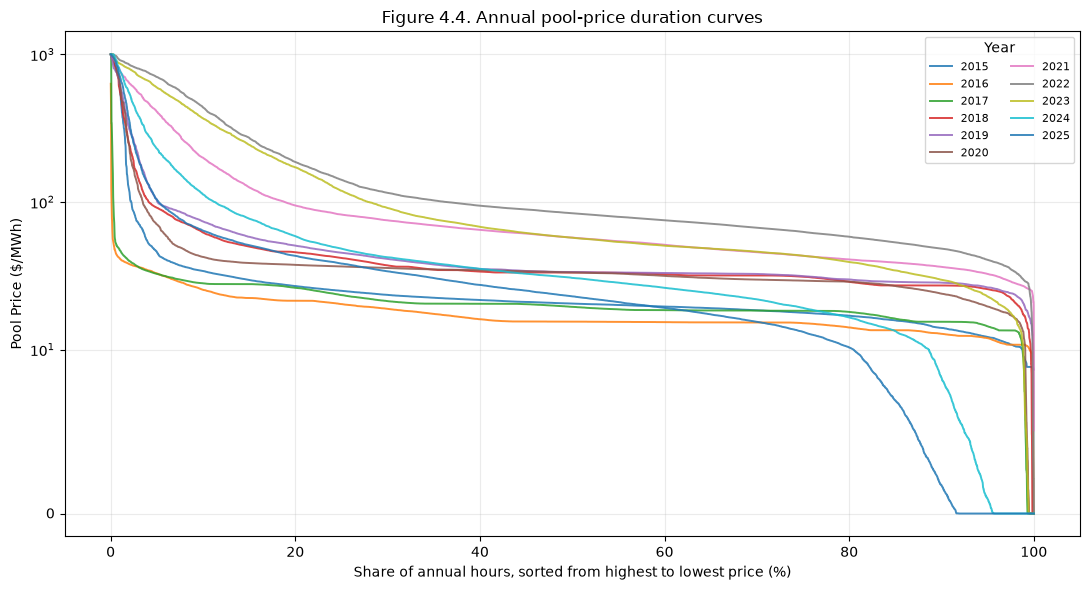

In [28]:
# ---------------------------------------------------------------------
# Plot annual price-duration curves
# ---------------------------------------------------------------------

price_duration = master[["year_alberta", price_col]].dropna().copy()

fig, ax = plt.subplots(figsize=(11, 6))

for year, group in price_duration.groupby("year_alberta"):
    sorted_prices = (
        group[price_col]
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    exceedance_rank_pct = (
        (np.arange(len(sorted_prices)) + 1)
        / len(sorted_prices)
        * 100
    )

    ax.plot(
        exceedance_rank_pct,
        sorted_prices,
        linewidth=1.4,
        alpha=0.85,
        label=int(year),
    )

ax.set_title("Figure 4.4. Annual pool-price duration curves")
ax.set_xlabel("Share of annual hours, sorted from highest to lowest price (%)")
ax.set_ylabel("Pool Price ($/MWh)")
ax.set_yscale("symlog", linthresh=10)
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, title="Year")

plt.tight_layout()
plt.show()


#### Annual Price-Duration Curves

Price-duration curves make the tail behaviour visible by sorting each year's hourly prices from highest to lowest. The relatively quiet 2016–2017 period exhibits a short upper tail, whereas 2021–2023 display both higher and substantially broader tails, reflecting more frequent and more severe price spikes.

Price-duration curves are a standard tool in electricity-market analysis because they distinguish the large number of ordinary operating hours from the relatively few high-price hours that drive volatility, scarcity, and many trading outcomes.

## Section 5 — When Do High-Price Hours Occur?

Having defined the relevant price tail, we now identify when high-price hours occur by year, month, hour, and event duration.

### 5.1 High-Price Hour Definition and Base Rate


In [29]:
# ---------------------------------------------------------------------
# Confirm the high-price definition and overall hourly frequency
# ---------------------------------------------------------------------

high_price_event = master[price_col].ge(200).rename("high_price_event")

high_price_summary = pd.Series({
    "total_hours": len(master),
    "high_price_hours": high_price_event.sum(),
    "high_price_rate_pct": high_price_event.mean() * 100,
})

display(high_price_summary.round(2))


total_hours            96432.00
high_price_hours        5667.00
high_price_rate_pct        5.88
dtype: float64

In [30]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by calendar year
# ---------------------------------------------------------------------

high_price_by_year = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("year_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
    )
)

high_price_by_year["high_price_rate_pct"] = high_price_by_year["high_price_rate"] * 100

display(high_price_by_year.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,high_price_rate_pct
year_alberta,,,,,
2015,8760,144,0.016,33.338,1.644
2016,8784,4,0.000,18.279,0.046
2017,8760,17,0.002,22.186,0.194
2018,8760,208,0.024,50.348,2.374
2019,8760,264,0.030,54.880,3.014
2020,8784,189,0.022,46.716,2.152
2021,8760,871,0.099,101.932,9.943
2022,8760,1663,0.190,162.463,18.984
2023,8760,1547,0.177,133.628,17.660


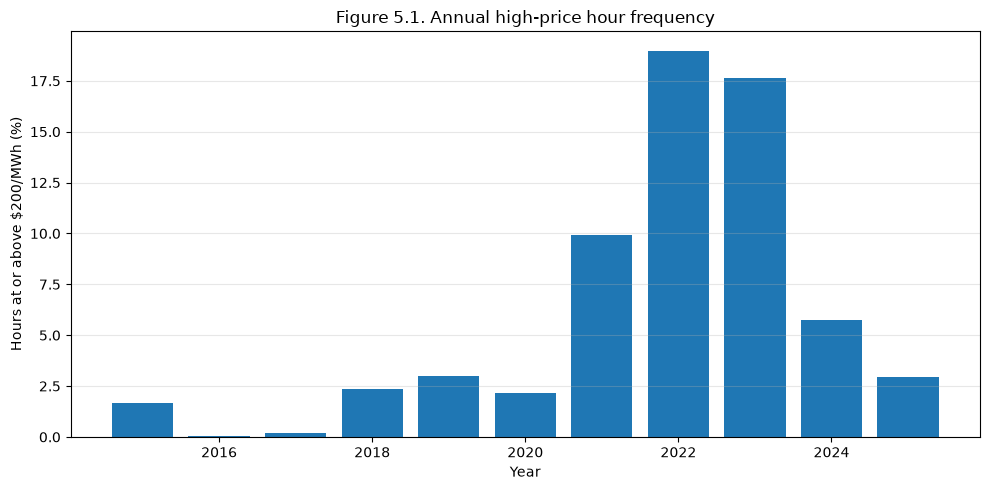

In [31]:
# ---------------------------------------------------------------------
# Visualize annual high-price frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    high_price_by_year.index,
    high_price_by_year["high_price_rate_pct"],
)

ax.set_title("Figure 5.1. Annual high-price hour frequency")
ax.set_xlabel("Year")
ax.set_ylabel("Hours at or above $200/MWh (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

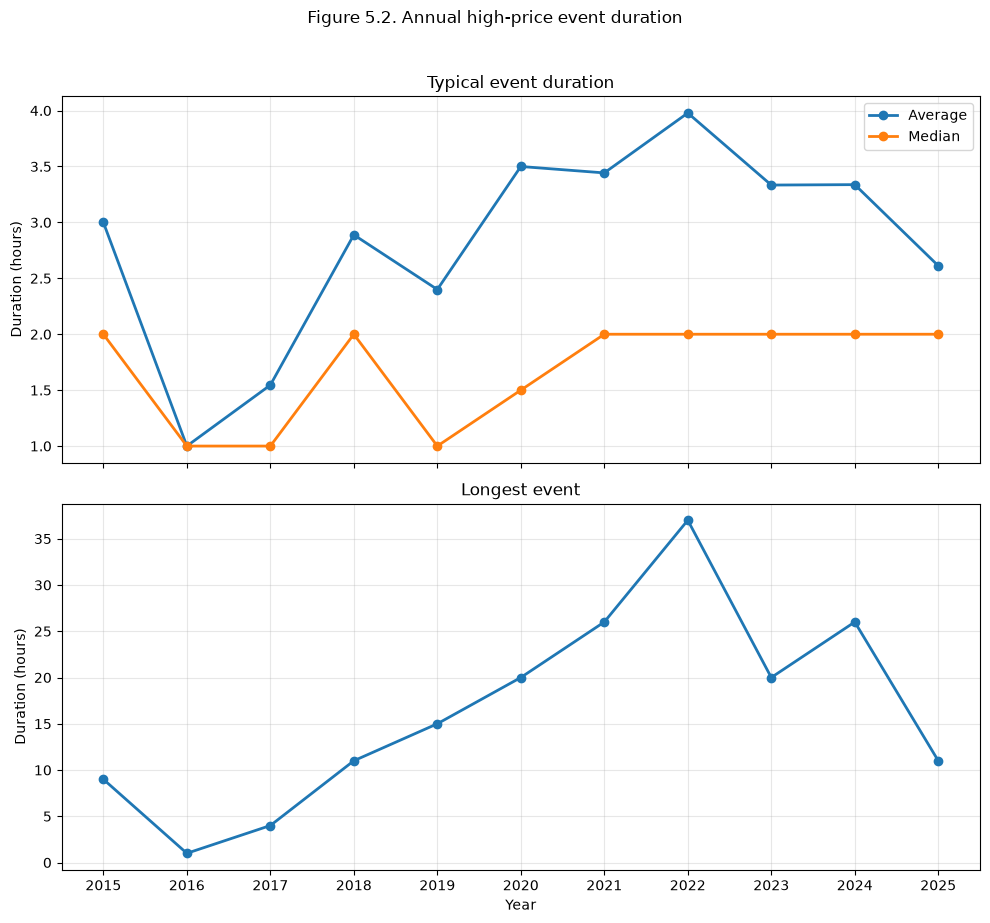

In [32]:
# ---------------------------------------------------------------------
# Visualize annual high-price event duration
# ---------------------------------------------------------------------

# Build consecutive high-price events
high_price_events = (
    pd.DataFrame({
        "timestamp_utc": master["timestamp_utc"],
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event.astype(bool),
    })
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

run_id = (
    high_price_events["high_price_event"]
    .ne(high_price_events["high_price_event"].shift(fill_value=False))
    .cumsum()
)

high_price_runs = (
    high_price_events.loc[high_price_events["high_price_event"]]
    .assign(run_id=run_id[high_price_events["high_price_event"]].to_numpy())
    .groupby("run_id")
    .agg(
        start_utc=("timestamp_utc", "min"),
        end_utc=("timestamp_utc", "max"),
        start_year_alberta=("year_alberta", "first"),
        duration_hours=("timestamp_utc", "size"),
    )
    .reset_index(drop=True)
)

annual_event_duration = (
    high_price_runs
    .groupby("start_year_alberta")
    .agg(
        average_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        maximum_duration_hours=("duration_hours", "max"),
    )
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

fig.suptitle(
    "Figure 5.2. Annual high-price event duration",
    y=1.02,
)

# ---------------------------------------------------------------------
# Average and median duration
# ---------------------------------------------------------------------

axes[0].plot(
    annual_event_duration.index,
    annual_event_duration["average_duration_hours"],
    marker="o",
    linewidth=2,
    label="Average",
)

axes[0].plot(
    annual_event_duration.index,
    annual_event_duration["median_duration_hours"],
    marker="o",
    linewidth=2,
    label="Median",
)

axes[0].set_title("Typical event duration")
axes[0].set_ylabel("Duration (hours)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------------------------------------------------------------
# Maximum duration
# ---------------------------------------------------------------------

axes[1].plot(
    annual_event_duration.index,
    annual_event_duration["maximum_duration_hours"],
    marker="o",
    linewidth=2,
)

axes[1].set_title("Longest event")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Duration (hours)")
axes[1].set_xticks(annual_event_duration.index)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### High-Price Hour Definition and Base Rate

An hour is labelled high price when the pool price is at least \$200/MWh. This threshold defines an hourly price state, not a direct observation of reserve deficiency, physical shortage, or involuntary curtailment. Across the study period, 5,667 of 96,425 observed hours (5.9%) met this criterion.

High-price hours were uncommon before 2021, increased sharply during 2021–2023, and then declined substantially in 2024 and 2025. The high-price rate fell from 17.7% in 2023 to 5.7% in 2024 and 2.9% in 2025. The 2025 rate is based on 8,753 observed hours.

High-price events also became more persistent during the 2021–2023 market regime. The typical event remained relatively short, with the median duration increasing from roughly one hour before 2021 to about two hours thereafter. However, the mean duration increased more substantially, and the longest annual events expanded from only one or two consecutive hours during the quietest years to 37 hours in 2022. Together, these results indicate that the 2021–2023 regime was characterized not only by more frequent high-price hours but also by a greater likelihood of prolonged periods of sustained price stress. The declines observed in 2024 and 2025 suggest that the frequency of high-price conditions subsequently moderated, with the 2025 rate returning close to levels observed in some pre-2021 years.

### 5.2 Consecutive High-Price Event Duration


In [33]:
# ---------------------------------------------------------------------
# Summarize persistence of consecutive high-price events
# ---------------------------------------------------------------------

high_price_events = (
    pd.DataFrame({
        "timestamp_utc": master["timestamp_utc"],
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event.astype(bool),
    })
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

run_id = high_price_events["high_price_event"].ne(
    high_price_events["high_price_event"].shift(fill_value=False)
).cumsum()

high_price_runs["duration_bucket"] = pd.cut(
    high_price_runs["duration_hours"],
    bins=[0, 1, 2, 5, np.inf],
    labels=["1 hour", "2 hours", "3-5 hours", "6+ hours"],
    right=True,
)

event_duration_summary = (
    high_price_runs
    .groupby("duration_bucket", observed=False)
    .agg(
        event_count=("duration_hours", "size"),
        high_price_hours=("duration_hours", "sum"),
        median_duration_hours=("duration_hours", "median"),
        max_duration_hours=("duration_hours", "max"),
    )
)

event_duration_summary["share_of_events_pct"] = (
    event_duration_summary["event_count"]
    / event_duration_summary["event_count"].sum()
    * 100
)

display(event_duration_summary.round(2))

display(
    high_price_runs
    .sort_values("duration_hours", ascending=False)
    .head(10)
)


,event_count,high_price_hours,median_duration_hours,max_duration_hours,share_of_events_pct
duration_bucket,,,,,
1 hour,657,657,1.0,1,39.04
2 hours,316,632,2.0,2,18.78
3-5 hours,406,1499,4.0,5,24.12
6+ hours,304,2879,8.0,37,18.06


,start_utc,end_utc,start_year_alberta,duration_hours,duration_bucket
882,2022-11-08 18:00:00+00:00,2022-11-10 06:00:00+00:00,2022,37,6+ hours
948,2022-12-19 19:00:00+00:00,2022-12-21 07:00:00+00:00,2022,37,6+ hours
930,2022-12-12 06:00:00+00:00,2022-12-13 08:00:00+00:00,2022,27,6+ hours
543,2021-12-27 13:00:00+00:00,2021-12-28 14:00:00+00:00,2021,26,6+ hours
1443,2024-01-13 06:00:00+00:00,2024-01-14 07:00:00+00:00,2024,26,6+ hours
801,2022-09-14 05:00:00+00:00,2022-09-15 05:00:00+00:00,2022,25,6+ hours
1444,2024-01-14 09:00:00+00:00,2024-01-15 06:00:00+00:00,2024,22,6+ hours
1442,2024-01-12 07:00:00+00:00,2024-01-13 04:00:00+00:00,2024,22,6+ hours
1315,2023-08-22 12:00:00+00:00,2023-08-23 07:00:00+00:00,2023,20,6+ hours
250,2020-01-15 11:00:00+00:00,2020-01-16 06:00:00+00:00,2020,20,6+ hours


#### Consecutive High-Price Event Duration

High-price hours are not only isolated hourly observations. Grouping consecutive hours with pool prices at or above \$200/MWh into events shows whether price stress appears as brief spikes or persistent operating conditions. Approximately 39% of events consist of a single high-price hour, while 18% persist for six hours or longer. Despite their relatively small share of events, these longer episodes account for approximately 51% of all high-price hours. The two longest observed events each lasted 37 consecutive hours and occurred in 2022.

This distinction matters because market participants experience prolonged periods of price stress differently from isolated spikes. Notebook 2 examines the conditions associated with event onset and persistence, while Notebook 8 evaluates whether the final forecasting system detects both reliably.

### 5.3 High-Price Hours by Month

In [34]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by calendar month
# ---------------------------------------------------------------------

month_order = [
    "january", "february", "march", "april",
    "may", "june", "july", "august",
    "september", "october", "november", "december",
]

high_price_by_month = (
    pd.DataFrame({
        "month_name_alberta": master["month_name_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("month_name_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
    )
    .reindex(month_order)
)

high_price_by_month["high_price_rate_pct"] = high_price_by_month["high_price_rate"] * 100

display(high_price_by_month.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,high_price_rate_pct
month_name_alberta,,,,,
january,8184,453,0.055,68.405,5.535
february,7464,455,0.061,69.438,6.096
march,8173,349,0.043,55.521,4.270
april,7920,346,0.044,55.755,4.369
may,8184,450,0.055,62.954,5.499
june,7920,572,0.072,73.991,7.222
july,8184,576,0.070,69.305,7.038
august,8184,622,0.076,76.658,7.600
september,7920,521,0.066,70.518,6.578


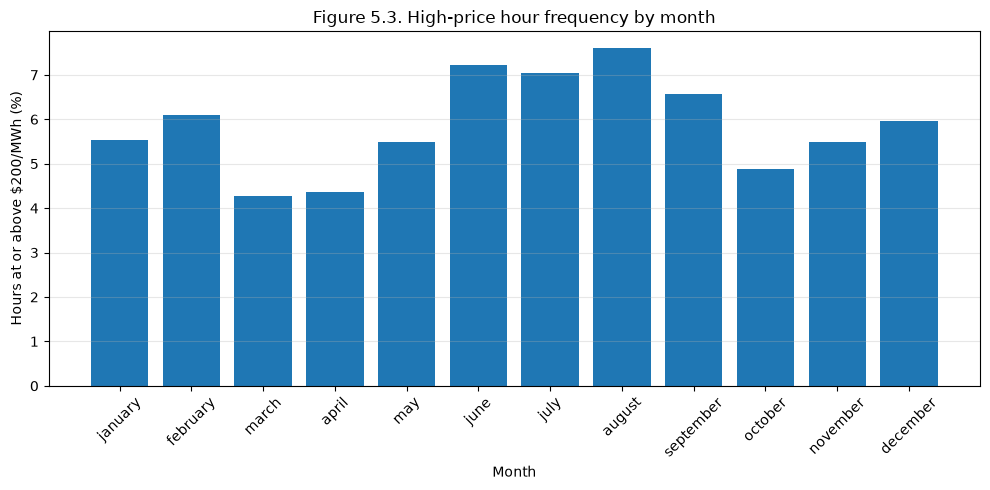

In [35]:
# ---------------------------------------------------------------------
# Visualize seasonal patterns in high-price frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    high_price_by_month.index,
    high_price_by_month["high_price_rate_pct"],
)

ax.set_title("Figure 5.3. High-price hour frequency by month")
ax.set_xlabel("Month")
ax.set_ylabel("Hours at or above $200/MWh (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### High-Price Hours by Month

Pooling all years, high-price hours occur most frequently during summer and are also elevated during winter. However, the year–month heatmap shows that this seasonal pattern is partly influenced by the concentration of the 2021–2023 high-price regime.

Notebook 4 examines whether summer and winter high-price hours arise from different combinations of temperature, load, and renewable generation, while Notebook 5 tests whether calendar seasonality remains informative across market regimes.

### 5.4 High-Price Hours by Hour

In [36]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by hour of day
# ---------------------------------------------------------------------

high_price_by_hour = (
    pd.DataFrame({
        "hour_alberta": master["hour_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("hour_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
    )
)

high_price_by_hour["high_price_rate_pct"] = high_price_by_hour["high_price_rate"] * 100

display(high_price_by_hour.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,median_price,high_price_rate_pct
hour_alberta,,,,,,
0,4018,82,0.020,42.352,29.760,2.041
1,4029,57,0.014,38.615,28.890,1.415
2,4007,41,0.010,36.751,28.220,1.023
3,4018,32,0.008,36.066,27.950,0.796
4,4018,52,0.013,37.270,28.395,1.294
5,4018,90,0.022,42.880,29.135,2.240
6,4018,198,0.049,57.529,31.625,4.928
7,4018,192,0.048,59.574,32.300,4.778
8,4018,205,0.051,61.850,33.250,5.102


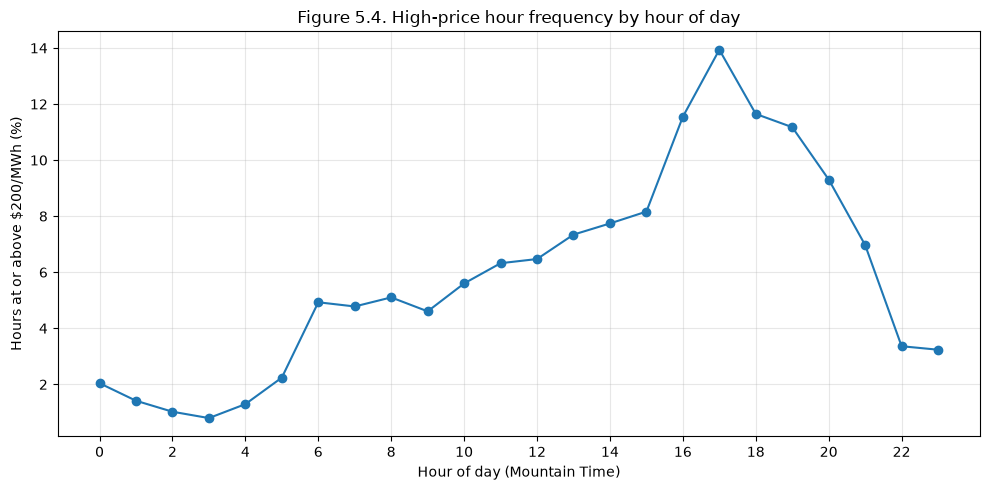

In [37]:
# ---------------------------------------------------------------------
# Visualize the intraday distribution of high-price hours
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    high_price_by_hour.index,
    high_price_by_hour["high_price_rate_pct"],
    marker="o",
)

ax.set_title("Figure 5.4. High-price hour frequency by hour of day")
ax.set_xlabel("Hour of day (Mountain Time)")
ax.set_ylabel("Hours at or above $200/MWh (%)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### High-Price Hours by Hour

The high-price-hour rate is lowest overnight, rises through the day, and peaks near 17:00 alongside the late-afternoon demand peak. Its intraday profile closely mirrors that of average pool price, although this similarity alone does not establish which underlying system conditions drive either pattern.

Notebook 2 tests whether net load and availability-adjusted system margin explain high-price hours better than gross load alone; Notebook 5 separates that physical relationship from recurring hour-of-day structure.

### 5.5 Year-Month High-Price Hour Map

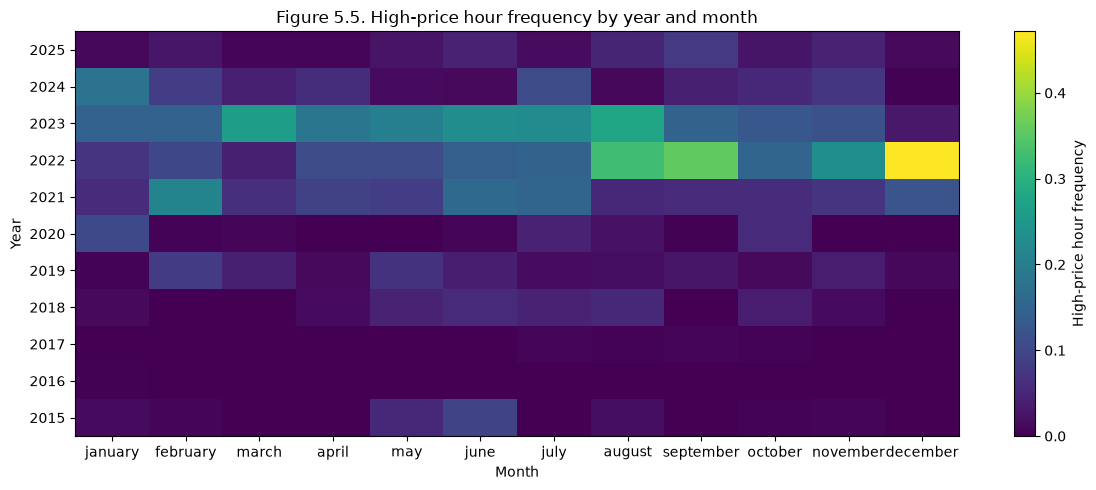

In [38]:
# ---------------------------------------------------------------------
# Visualize the monthly evolution of high-price frequency
# ---------------------------------------------------------------------

high_price_calendar = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "month_alberta": master["month_alberta"],
        "high_price_event": high_price_event,
    })
    .groupby(["year_alberta", "month_alberta"])["high_price_event"]
    .mean()
    .unstack()
    .reindex(columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(high_price_calendar, aspect="auto", origin="lower")
ax.set_title("Figure 5.5. High-price hour frequency by year and month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticks(range(12))
ax.set_xticklabels(month_order)
ax.set_yticks(range(len(high_price_calendar.index)))
ax.set_yticklabels(high_price_calendar.index)
plt.colorbar(image, ax=ax, label="High-price hour frequency")

plt.tight_layout()
plt.show()


#### Monthly Evolution of High-Price Hours

The heatmap reveals persistent market regimes rather than isolated high-price months. High-price months were sporadic before 2021, became sustained throughout 2021–2023, and moderated during 2024 and 2025. December 2022 was the most severe month, with nearly half of all hours priced at or above \$200/MWh.

The persistence of elevated prices across consecutive months suggests common regime-level drivers—such as fuel costs, generation availability, outages, or sustained net-load conditions—rather than independent hourly events. Notebook 2 characterizes these scarcity regimes, Notebook 5 examines their temporal stability, and Notebooks 6–8 carry them into time-aware forecast evaluation.

## Research Roadmap

Notebook 1 establishes that Alberta’s market underwent substantial structural change, developed recurring but unstable operating patterns, and experienced markedly different price regimes. The remaining notebooks separate the principal mechanisms before evaluating their forecasting value.

| Notebook | Primary research question |
| --- | --- |
| **Notebook 2 — Scarcity Regimes and System Tightness** | Why did high-price conditions intensify despite a larger reported generation fleet, and do net load, thermal availability, outages, and intertie capability explain system tightness? |
| **Notebook 3 — Price Formation: Fuel Economics and Marginal Cost** | How do natural-gas prices, spark spreads, and thermal generation economics explain ordinary pool-price variation? |
| **Notebook 4 — Weather, Demand, and Renewable Variability** | How do temperature, demand, wind, solar, and seasonal weather conditions affect net load and market outcomes? |
| **Notebook 5 — Temporal Patterns and Market Memory** | Which hourly, weekly, seasonal, lagged, and regime-dependent relationships remain stable through time? |
| **Notebook 6 — Baseline Forecast Models** | How much forecast performance can be achieved using persistence, seasonal-naive, regression, and logistic baselines? |
| **Notebook 7 — Machine-Learning Forecast Models** | Do nonlinear models improve price and high-price-event forecasts after strict time-based validation and calibration? |
| **Notebook 8 — Price Forecasting and Extreme-Event Prediction** | How reliably can the final forecasting system predict ordinary prices, extreme-event onset, and event persistence across horizons and market regimes? |

This sequence separates market explanation from prediction. Notebooks 2–5 investigate the underlying mechanisms, while Notebooks 6–8 test whether those relationships provide stable out-of-sample forecasting value.

## Conclusion

Between 2015 and 2025, Alberta’s electricity market became larger, more diverse, and more operationally complex. Electricity demand increased across the load profile, coal generation exited as a separately reported category, natural gas became the principal source of dispatchable generation, and wind and solar expanded substantially. Reported generation capacity grew by approximately 7 GW, while Alberta’s annual electricity-trade position shifted from sustained net imports toward net exports by 2024.

A larger supply stack did not produce consistently lower or less volatile prices. The market moved through several distinct price regimes, culminating in the sustained high-price conditions of 2021–2023 before moderating in 2024 and 2025. High-price hours also became more persistent during the elevated-price regime, demonstrating that Alberta’s price tail reflects prolonged periods of market stress as well as isolated price spikes.

The descriptive evidence suggests that nameplate capacity and gross demand are insufficient on their own to explain these outcomes. The more important question is how much usable supply remains relative to the demand that must be served at a particular hour. This makes net load, generation availability, outages, intertie capability, fuel economics, and weather-dependent renewable production central to understanding how Alberta’s market moves from ordinary operation into scarcity.

Notebook 1 establishes the market context and the empirical patterns that require explanation. The following notebooks separate the physical, economic, weather-related, and temporal mechanisms behind those patterns before testing whether they provide stable out-of-sample forecasting value.